# GPU-Accelerated Quantitative Portfolio Optimization with NVIDIA cuOpt™
[![Click here to deploy.](https://brev-assets.s3.us-west-1.amazonaws.com/nv-lb-dark.svg)](https://brev.nvidia.com/launchable/deploy/now?launchableID=env-360InRZzyHqDnJYQKIxaSggF8xI)

This notebook introduces NVIDIA's GPU-Accelerated Portfolio Optimization developer blueprint. We use the Mean-CVaR model to solve the problem of portfolio asset allocation. We show step-by-step how to pre-process input data, build the optimization model, solve the problem, and backtest the portfolio performance.

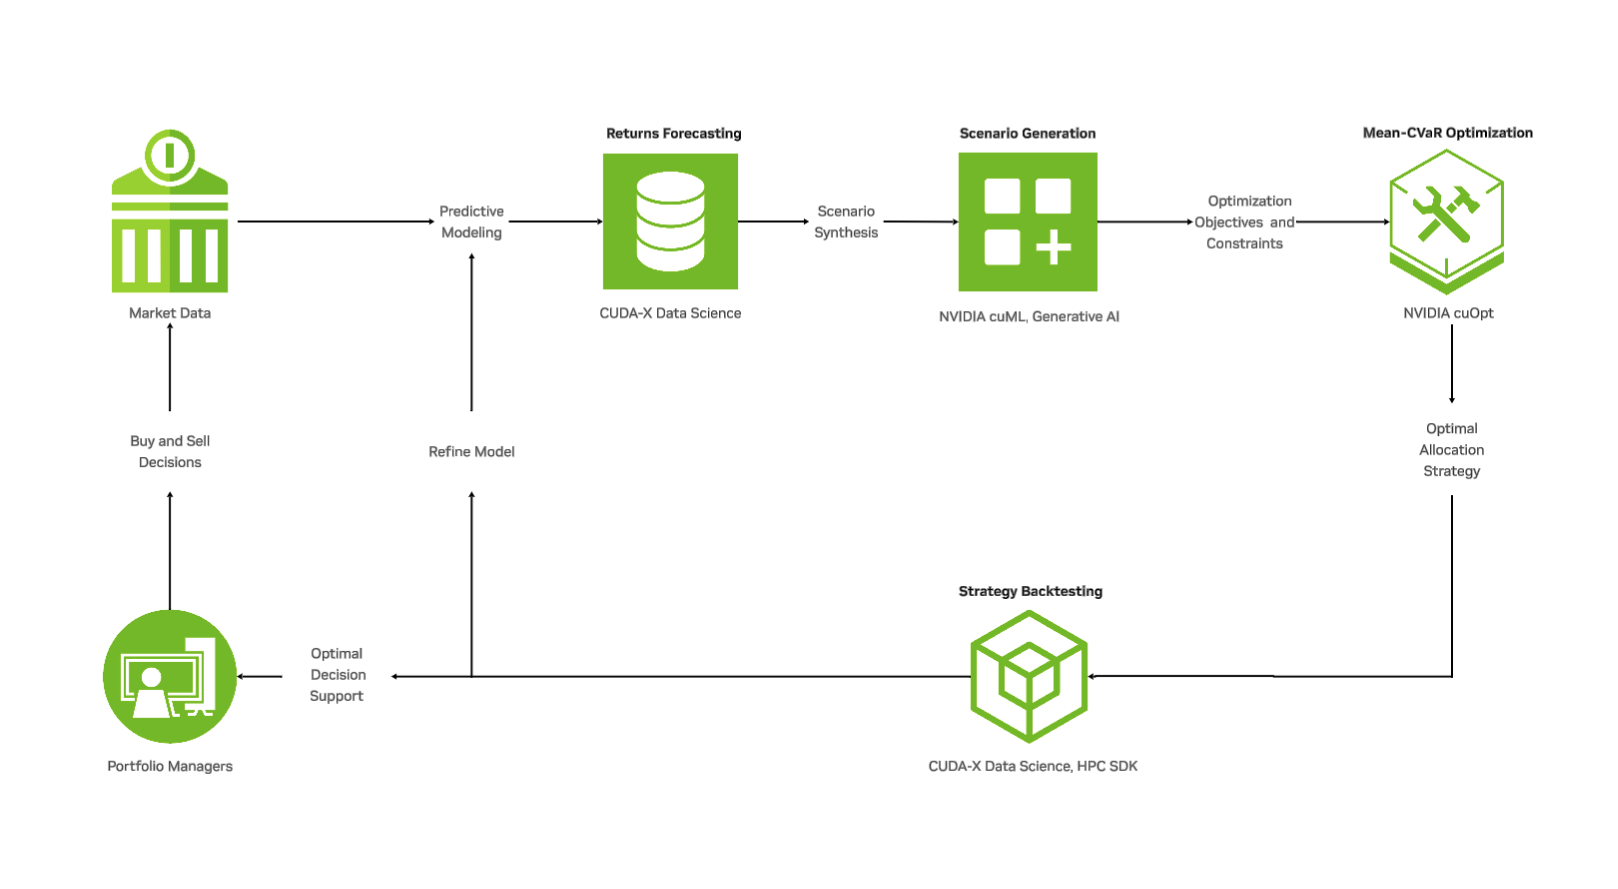

In particular, we will cover the following in this notebook: 
- **Portfolio Optimization Setup** – Clone repository, install dependencies, and configure environment
- **Data-preprocessing** - Calculate daily returns from input price data 
- **Scenario generation** - Use cuML KDE to model returns distribution and generate return scenarios 
- **Model Building** - Build the optimization problem with optional constraints
- **Solving Optimization on GPU** – Call GPU/CPU solvers with customizable settings to solve the problem
- **Backtesting** - Visualize and evaluate optimized portfolio
- **Comparing CPU and GPU Performance** – Evaluate performance solving optimization problem on GPU vs CPU
- **Generating Efficient Frontier** - Create an efficient frontier by solving optimization for different risk aversion levels
- **Backtesting Re-Balancing Strategies** - Re-balance portfolios over time with different strategies

## Table of Contents
---
### Basic Walk-through:
1. [Portfolio Optimization Setup](#portfolio-optimization-setup)
   - GPU Check
   - Import Libraries

2. [Introduction to Mean-CVaR Optimization](#build-a-mean-cvar-problem)
   - Mathematical Formulation

3. [Data Preprocessing and Model Setup](#data-preprocessing-and-model-setup)
   - Data Preparation
   - Define Problem Parameters
   - Build Mean-CVaR Problem

4. [Solve CVaR Optimization](#solve-cvar-optimization)
   - cuOpt GPU LP Solver
   - CPU Solver Comparison
   - Portfolio Visualization
   - cuOpt GPU MILP Solver

5. [Backtest Portfolio](#backtest-portfolio)
   - Testing Methods
   - Performance Metrics
   - Benchmark Comparison

6. [GPU vs. CPU: Comparison over Different Regimes](#gpu-vs-cpu-comparison-over-different-regimes)
   - Regime Analysis
   - Performance Comparison

7. [Appendix](#appendix)
   - Optional Parameter Constraints
   - cuOpt Python API
---
### Advanced topics: 
8. [Efficient Frontier](#efficient-frontier)

9. [Rebalancing Strategies](#rebalancing-strategies)

   - Percentage change strategy
   - Drift from optimal strategy

10. [Mean-Variance Portfolio Optimization](#mean-variance)
   - Quadratic Program (QP) Markowitz formulation
   - Solve with cuOpt GPU
   - CPU solver comparison

---

**Before you start, please make sure you select the `Portfolio Optimization` kernel.**


---

<a id='portfolio-optimization-setup'></a>
## 1. Portfolio Optimization Setup

Now that the environment has been configured in `launchable-setup.ipynb`, let's verify GPU availability and import the necessary libraries for portfolio optimization.


In [1]:
!nvidia-smi

Wed Apr 22 18:10:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:DF:00.0 Off |                    0 |
| N/A   36C    P0             78W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Import Libraries

Import the portfolio optimization modules and other required packages.


In [2]:
import os
import cvxpy as cp

from cufolio import cvar_optimizer, cvar_utils, utils
from cufolio.cvar_parameters import CvarParameters
from cufolio.settings import (
    ApiSettings,
    KDESettings,
    ReturnsComputeSettings,
    ScenarioGenerationSettings,
)

---

<a id='build-a-mean-cvar-problem'></a>
## 2. Introduction to Mean-CVaR Optimization

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-CVaR Optimization</h4>
The Mean-CVaR model captures the risk-return trade-off, aiming to maximize expected return while minimizing Conditional Value-at-Risk.

Traditionally, variance of portfolio returns is used as the measure of risk. Here, we use <strong>Conditional Value-at-Risk (CVaR)</strong> as an alternative risk measure because it provides a more robust assessment of potential tail losses, and allows a data-driven approach to portfolio optimization without making assumptions on the underlying returns distribution. CVaR measures the average worst-case loss of a return distribution. Formally, for a loss random variable L,
$$\text{CVaR} = {E}[L| L \leq \text{VaR}_\alpha (L)]$$
where  $\text{VaR}(L) = \inf\{l: P(L \leq l) \geq \alpha  \}$ is the $\alpha$-quantile of the loss distribution. CVaR is a more appropriate risk measure for portfolios that may contain assets with asymmetric return distribution - it has replaced Value-at-Risk(VaR) in Basel III market-risk rules; Mathematically, CVaR is a coherent risk measure—satisfying subadditivity, translation invariance, positive homogeneity, and monotonicity—which aligns with the diversification principles. Moreover, it has a computationally tractable transformation as a scenario-based optimization: for confidence level $\alpha$, the CVaR of portfolio ${w}$ can be written in abstract form as 
$$\text{CVaR}({w}) = \min_t\left\{t + \frac{1}{1-\alpha}\sum_{\omega \in \Omega}p(\omega)\max \{\text{loss}({w},\omega) - t, 0\}\right\}, $$
where $\Omega$ is the probability space of returns scenarios and $p(\omega)$ is the probability of a particular scenario $\omega \in \Omega$. Intuitively, this expression represents the portfolio’s average loss below the $\alpha$-quantile of all return scenarios. This scenario-based formulation makes CVaR more robust regardless whether the asset returns distribution is Gaussian or not. When we use linear loss, i.e. $\text{loss}(w,\omega) = -R(\omega){w}$, with $R$ as the return scenarios matrix of size (num_scenarios, num_assets),  the minimization of the CVaR can be transformed into a linear program by replacing the $\max\{\cdot,0\}$ non-negative operator with an auxiliary variable ${u}$: 

\begin{align*}
\text{minimize} \; \quad & t + \frac{1}{1-\alpha}{p}^\top {u},\\
\text{subject to} \quad &{u} +t \geq -R^\top {w},\\
&u\geq 0
\end{align*}

Then, we add constraints to model real-world trading limitations:
- Concentration limits on single assets
- Amount invested in risk-free assets (cash)
- Investment budgets
- Leverage constraints
- Turnover from an existing portfolio
- Cardinality constraints (maximum number of assets allowed in the portfolio)


The mathematical formulation of the problem is given as follows: 
\begin{align*}
\text{maximize } \quad &\mu^\top {w} - \lambda_{\text{ risk}}\left(t + \frac{1}{1-\alpha}p^\top {u}\right)\\
\text{subject to} \quad &{u} +t \geq -R^\top {w}, \, u \geq 0 \quad \text{ (CVaR)}\\
& \sum_i w_i + c = 1\quad \text{(self-financing)}\\
& w_i^{\text{ min}} \leq w_i \leq w_i^{\text{ max}}, \forall i \quad \text{ (concentration)}\\
& c^{\text{ min}} \leq c \leq c^{\text{ max}} \quad \text{ (cash)}\\
& L= \Vert {w} \Vert_1 \leq L^{\text{ limit}} \quad\text{ (leverage)}\\
& T = \Vert {w} - {w}_{\text{ pre}}\Vert_1 \leq T^{\text{ limit}}\quad \text{ (turnover)}
\end{align*}
</div>

## 3. Data Preprocessing and Model Setup
<a id='data-preprocessing-and-model-setup'></a>

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Overview</h4>
We start with an example using a 397-stock subset of the S&P 500 stocks. We aim to build a long-short portfolio that maximizes risk-adjusted returns while meeting custom trading constraints.
</div> 

### 3.1 Data Preparation

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Data Loading</h4>
We load closing prices from <code>2021-01-01</code> to <code>2024-01-01</code> and compute daily log-returns.
<ul>
<li><strong>Historical Dataset</strong> (<code>data_path</code>): CSV file with adjusted closing prices</li>
<li><strong>Regime Information</strong> (<code>regime_dict</code>): select the market regime</li>
<li><strong>Computation Setting</strong> (<code>returns_compute_settings</code>): return type (LOG / NORMAL) and frequency (default 1 = daily)</li>
</ul>
</div>



#### Disclaimer

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>

In [3]:
# User inputs for S&P 500 example
dataset_name = "sp500"
dataset_format = "csv"
data_path = f"../data/stock_data/{dataset_name}.{dataset_format}"

# Download data if not exists
if not os.path.exists(data_path):
    utils.download_data(data_path)

In [4]:
# Set date range
regime_name = "recent" 
time_range = ("2021-01-01", "2024-01-01")


# Define the regime for this example
regime_dict = {"name": regime_name, "range": time_range}

# Define the settings for returns computation
returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)

# Compute returns from price data
returns_dict = utils.calculate_returns(
    data_path,
    regime_dict,
    returns_compute_settings
)

### 3.2 Scenario Generation

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Scenario Generation</h4>
Assume the return distribution is stationary over the optimization period and use historical returns to approximate future ones. We use <code>cuml.KDE</code> on GPU or <code>sklearn.KDE</code> on CPU to fit the return distribution and sample scenarios. Also supports fitting a Multivariate Gaussian distribution. Configure via <code>scenario_generation_settings</code>.
</div>


In [5]:
# Define the settings for scenario generation
scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Generate return scenarios from KDE
returns_dict = cvar_utils.generate_cvar_data(
    returns_dict,
    scenario_generation_settings
)

### 3.3 Define Optimization Parameters

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 CvarParameters</h4>
We define a <code>CvarParameters</code> object to encapsulate key constraints and settings.
<br><br>
<strong>Required:</strong> <code>w_min</code>, <code>w_max</code>, <code>risk_aversion</code>, <code>confidence</code>, <code>num_scen</code>, <code>fit_type</code> — these establish the basic optimization framework.
<br><br>
<strong>Optional:</strong> <code>T_tar</code> (turnover), <code>cvar_limit</code> (max CVaR threshold), <code>cardinality</code> (portfolio size limit). Setting any to a non-<code>None</code> value adds the corresponding constraint.
</div>

In [6]:
# Define CVaR optimization parameters for the S&P 500 example
cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality=None,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95  # CVaR confidence level (alpha)
)

### 3.4 Build Mean-CVaR Problem

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Problem Construction</h4>
We take the processed data <code>returns_dict</code> and the problem parameters <code>cvar_params</code> and formulate the problem <code>cvar_problem</code>.
</div> 


In [7]:
# Instantiate CVaR optimization problem for the S&P 500 example
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params
)

---

<a id='solve-cvar-optimization'></a>
## 4. Solve CVaR Optimization

### 4.1 cuOpt GPU LP Solver

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 cuOpt Solver Modes</h4>
The cuOpt LP solver supports four solve methods (<code>solver_method</code>):
<ol>
<li><strong>PDLP</strong> — three modes via <code>solver_mode</code>:
  <ul>
  <li><em>Stable2</em>: balance speed and accuracy</li>
  <li><em>Methodical1</em>: prioritize accuracy</li>
  <li><em>Fast1</em>: prioritize speed</li>
  </ul>
</li>
<li><strong>Dual Simplex</strong></li>
<li><strong>Barrier Method</strong></li>
<li><strong>Concurrent</strong>: runs all three and returns the fastest</li>
</ol>
See <a href="https://docs.nvidia.com/cuopt/user-guide/latest/introduction.html">cuOpt documentation</a> for details.
</div>


In [8]:
# GPU solver settings
gpu_solver_settings = {"solver": cp.CUOPT, 
                       "verbose": False, 
                       "solver_method": "PDLP", 
                       "time_limit":15, 
                       "optimality": 1e-4
                       }

# Solve on GPU
gpu_results, gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)


CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              387
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002527 (0.2527%)
CVaR (95%):          0.025691 (2.5691%)
Objective Value:     -0.001410

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.3065 seconds
CVXPY API Overhead:  0.2048 seconds
Solve Time:          0.8524 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.302 ( 30.17%)
MCK         0.170 ( 16.99%)
NVDA        0.144 ( 14.41%)
JBL         0.099 (  9.91%)
IRM         0.099 (  9.89%)
IT          0.093 (  9.29%)
PWR         0.083 (  8.27%)
COP  

In [9]:
gpu_results

regime          recent
solver           CUOPT
solve time    0.852369
return        0.002527
CVaR          0.025691
obj           -0.00141
dtype: object

### 4.2 Solve on CPU solver

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🔄 CPU Comparison</h4>
Using CVXPY as the modeling API, we can easily switch to any CPU solver to solve the same problem. Compare performance and verify that CPU and GPU results match up to the tolerance level — just change the solver in the settings dictionary.
</div>

In [10]:
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=ApiSettings(api="cvxpy")
)

# CPU solver settings
cpu_solver_settings = {"solver":cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4}

# Solve on CPU
cpu_results, cpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=cpu_solver_settings)


CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              387
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002522 (0.2522%)
CVaR (95%):          0.025634 (2.5634%)
Objective Value:     -0.001408

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.3243 seconds
CVXPY API Overhead:  0.2921 seconds
Solve Time:          26.4931 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.300 ( 29.99%)
MCK         0.171 ( 17.12%)
NVDA        0.145 ( 14.47%)
IRM         0.100 ( 10.04%)
JBL         0.099 (  9.86%)
IT          0.091 (  9.09%)
PWR         0.082 (  8.20%

In [11]:
# Compare results between GPU and CPU solvers
utils.compare_results(gpu_results, cpu_results)


SOLVER COMPARISON
Solver          solve time   obj          CVaR         return      
----------------------------------------------------------------------
CUOPT           0.852369     -0.001410    0.025691     0.002527    
CLARABEL        26.493150    -0.001408    0.025634     0.002522    

Objective Differences:
  CUOPT vs CLARABEL: 0.00000201



### 4.3 Optional: Visualize Optimized Portfolio

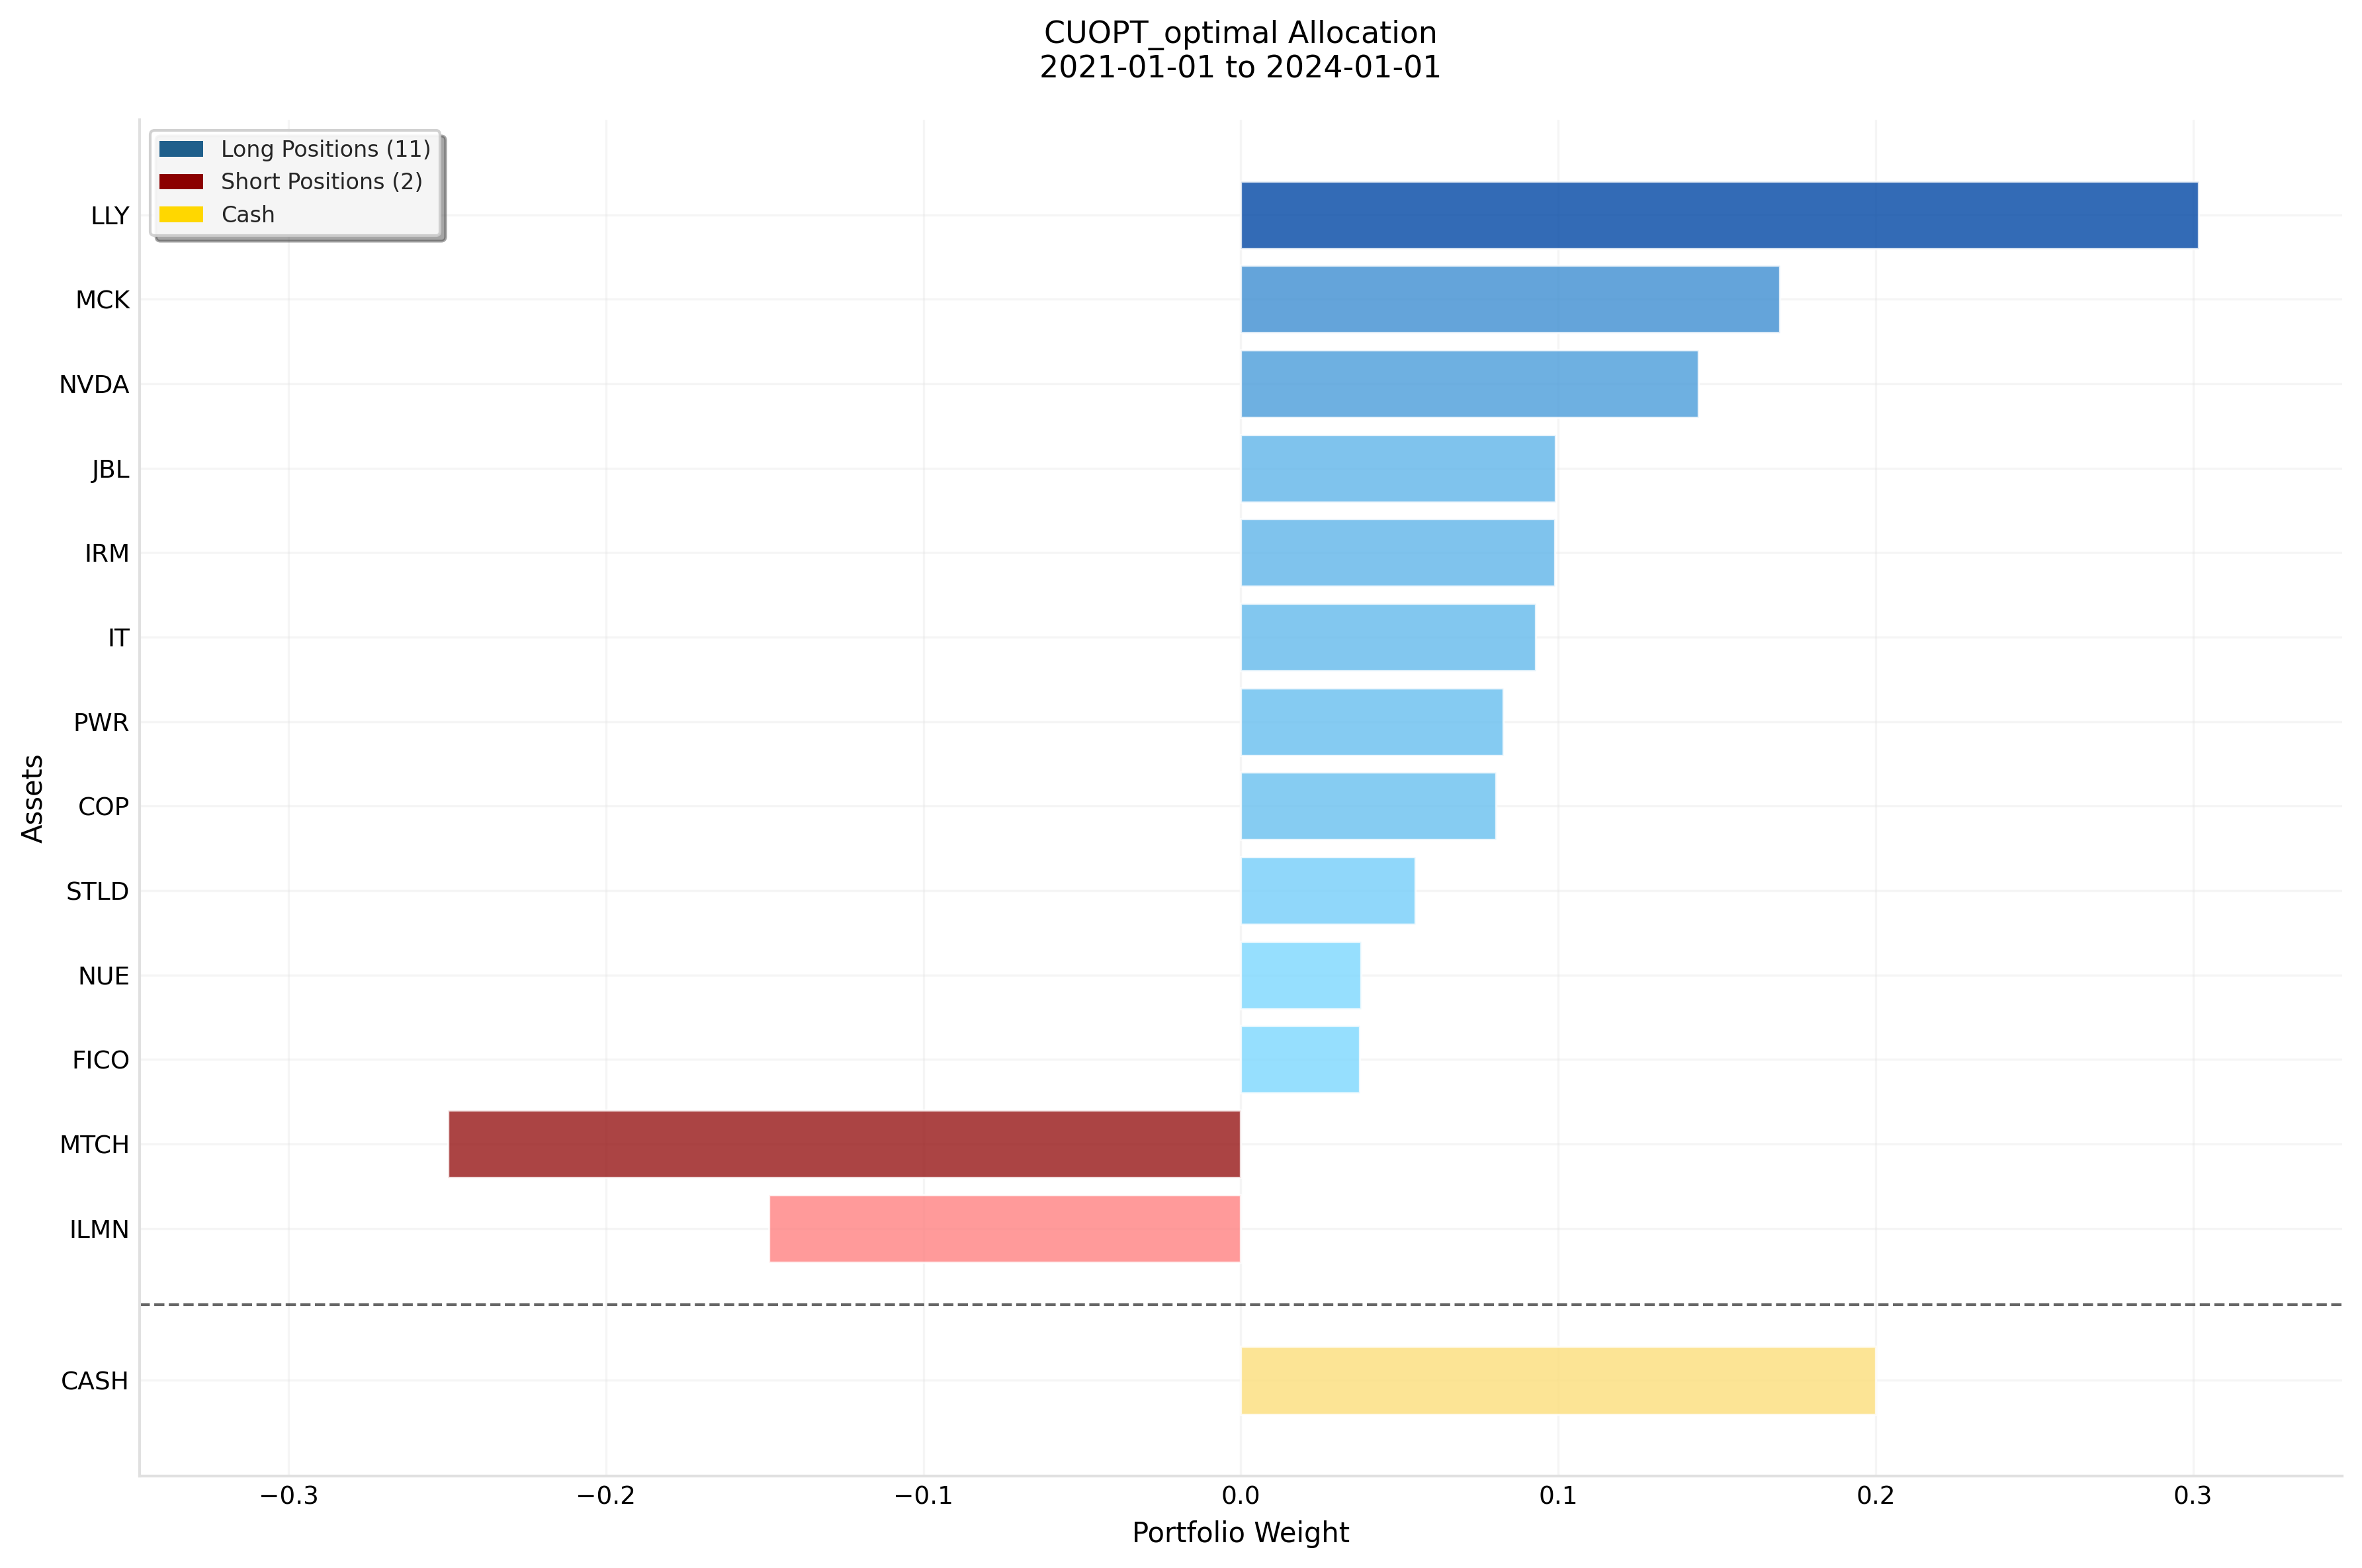

In [12]:
# Plot portfolio
ax = gpu_portfolio.plot_portfolio(show_plot = True, min_percentage = 1)

### 4.4 Adding Cardinality Constraint: Mixed-Integer Linear Program 

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Cardinality Constraint (MILP)</h4>
A <strong>cardinality constraint</strong> limits the maximum number of assets held in the portfolio, promoting sparsity and reducing transaction costs. This constraint transforms the problem into a <strong>Mixed-Integer Linear Program (MILP)</strong> because it requires binary decision variables to track whether each asset is included.

**Mathematical Formulation:**

We introduce binary variables $y_i \in \{0,1\}$ for each asset $i$, where:
- $y_i = 1$ if asset $i$ is held in the portfolio (i.e., $w_i \neq 0$)
- $y_i = 0$ otherwise

The cardinality constraint is then:
$$\sum_{i=1}^{N} y_i \leq K$$
where $K$ is the maximum number of assets allowed. To link the binary variables with the continuous weights, we add:
$$w_i^{\min} \cdot y_i \leq w_i \leq w_i^{\max} \cdot y_i, \quad \forall i$$

This ensures that $w_i = 0$ when $y_i = 0$, and $w_i$ can take non-zero values only when $y_i = 1$. The presence of integer decision variables $y_i$ makes this a MILP.

The complete problem can be written as follows:

\begin{align*}
\text{maximize } \quad & \mu^\top {w} - \lambda_{risk}\left(t + \frac{1}{1-\alpha}p^\top {u}\right),\\
\text{subject to } \quad & {1}^\top {w} = 1,\\
&{u} \geq -R^\top {w} - t,\\
& {w}^{\min} \circ {y} \leq {w} \leq {w}^{\max} \circ {y}, c^{\min} \leq c \leq c^{\max},\\
& L= \Vert {w} \Vert_1 \leq L^{tar},\\
& T = \Vert {w} - {w}_{b}\Vert_1 \leq T^{tar},\\
& \sum{{y}_i} \leq K,\\
&{y}_i \in \{0,1\}^N.
\end{align*}

**Model Set-Up:** 

To set up a MILP problem, we just need to set the `cardinality` to an integer number (max number of assets allowed in the portfolio) when instantiating the `CvarParameters` class. cuOpt offers MILP solvers with a GPU-accelerated heuristics algorithm and a CPU branch-and-cut algorithm. Since MILPs are much challenging to solve in general, we should expect a longer solve time. After solving, one can verify that the number of assets in the portfolio is indeed less than or equal to the cardinality constraint.
</div> 


In [13]:
# Define CVaR optimization parameters for the S&P 500 example
milp_cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality=10,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95,  # CVaR confidence level (alpha)
)

# Instantiate the MILP problem
milp_cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=milp_cvar_params
)

# cuOpt MILP solver settings
gpu_solver_settings = {"solver": cp.CUOPT, 
                       "verbose": False, 
                       "time_limit":200, 
                       "mip_absolute_tolerance": 1e-4
                       }

# Solve the MILP problem
milp_results, milp_portfolio = milp_cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)

MIXED-INTEGER LINEAR PROGRAMMING (MILP) SETUP
Cardinality Constraint: K ≤ 10 assets

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              387
Confidence Level:    95.0%
Cardinality Limit:   10 assets

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002559 (0.2559%)
CVaR (95%):          0.026757 (2.6757%)
Objective Value:     -0.001396

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.3223 seconds
CVXPY API Overhead:  0.5604 seconds
Solve Time:          45.9428 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (8 assets)
-------------------------
LLY         0.325 ( 32.53%)
MCK         0.185 ( 18.47%)
NVDA        0.176 ( 17.64%)
PW

## 5. Backtest Portfolio
<a id='backtest-portfolio'></a>

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Backtesting</h4>
The <code>portfolio_backtester</code> evaluates portfolio performance against historical data and benchmarks.
<br><br>
<strong>Testing Methods:</strong> Historical returns, KDE Simulation, Gaussian Simulation
<br>
<strong>Performance Metrics:</strong> Sharpe Ratio, Sortino Ratio, Maximum Drawdown
<br>
<strong>Benchmarking:</strong> Compares against an equal-weight portfolio by default; custom benchmarks supported.
<br><br>
The <code>cut_off_date</code> marks the boundary between training data (used for optimization) and test data (used for out-of-sample evaluation), letting you test robustness to regime shifts.
</div> 

In [14]:
# Define test regime and calculate test returns
test_regime_dict = {"name": "test_recent", "range": ("2023-09-01", "2024-07-01")}
test_returns_dict = utils.calculate_returns(data_path, test_regime_dict, returns_compute_settings)

# Backtest settings
test_method = "historical"
risk_free = 0.0

,returns,cumulative returns,mean portfolio return,sharpe,sortino,max drawdown
portfolio name,,,,,,
CUOPT_optimal,"[0.004107747951555543, 0.0015762834505209983, ...","[1.0041161963121232, 1.0057002161589246, 1.015...",0.002978,3.571587,6.4975,0.076312
AMZN-JPM,"[-0.00644176953853743, -0.010386320690701063, ...","[0.99357893417881, 0.9833127111686009, 0.99476...",0.001548,1.966758,3.128699,0.136418
AAPL-MSFT,"[0.009376142434524547, -0.0117968465542046, -0...","[1.00942023615994, 0.9975822234218238, 0.98363...",0.001181,1.867662,2.827683,0.073053
NKE-MCD,"[-0.00916427759240435, -0.009069080438737612, ...","[0.9908775864174175, 0.9819318639337113, 0.983...",-0.000643,-1.054598,-1.26928,0.192486


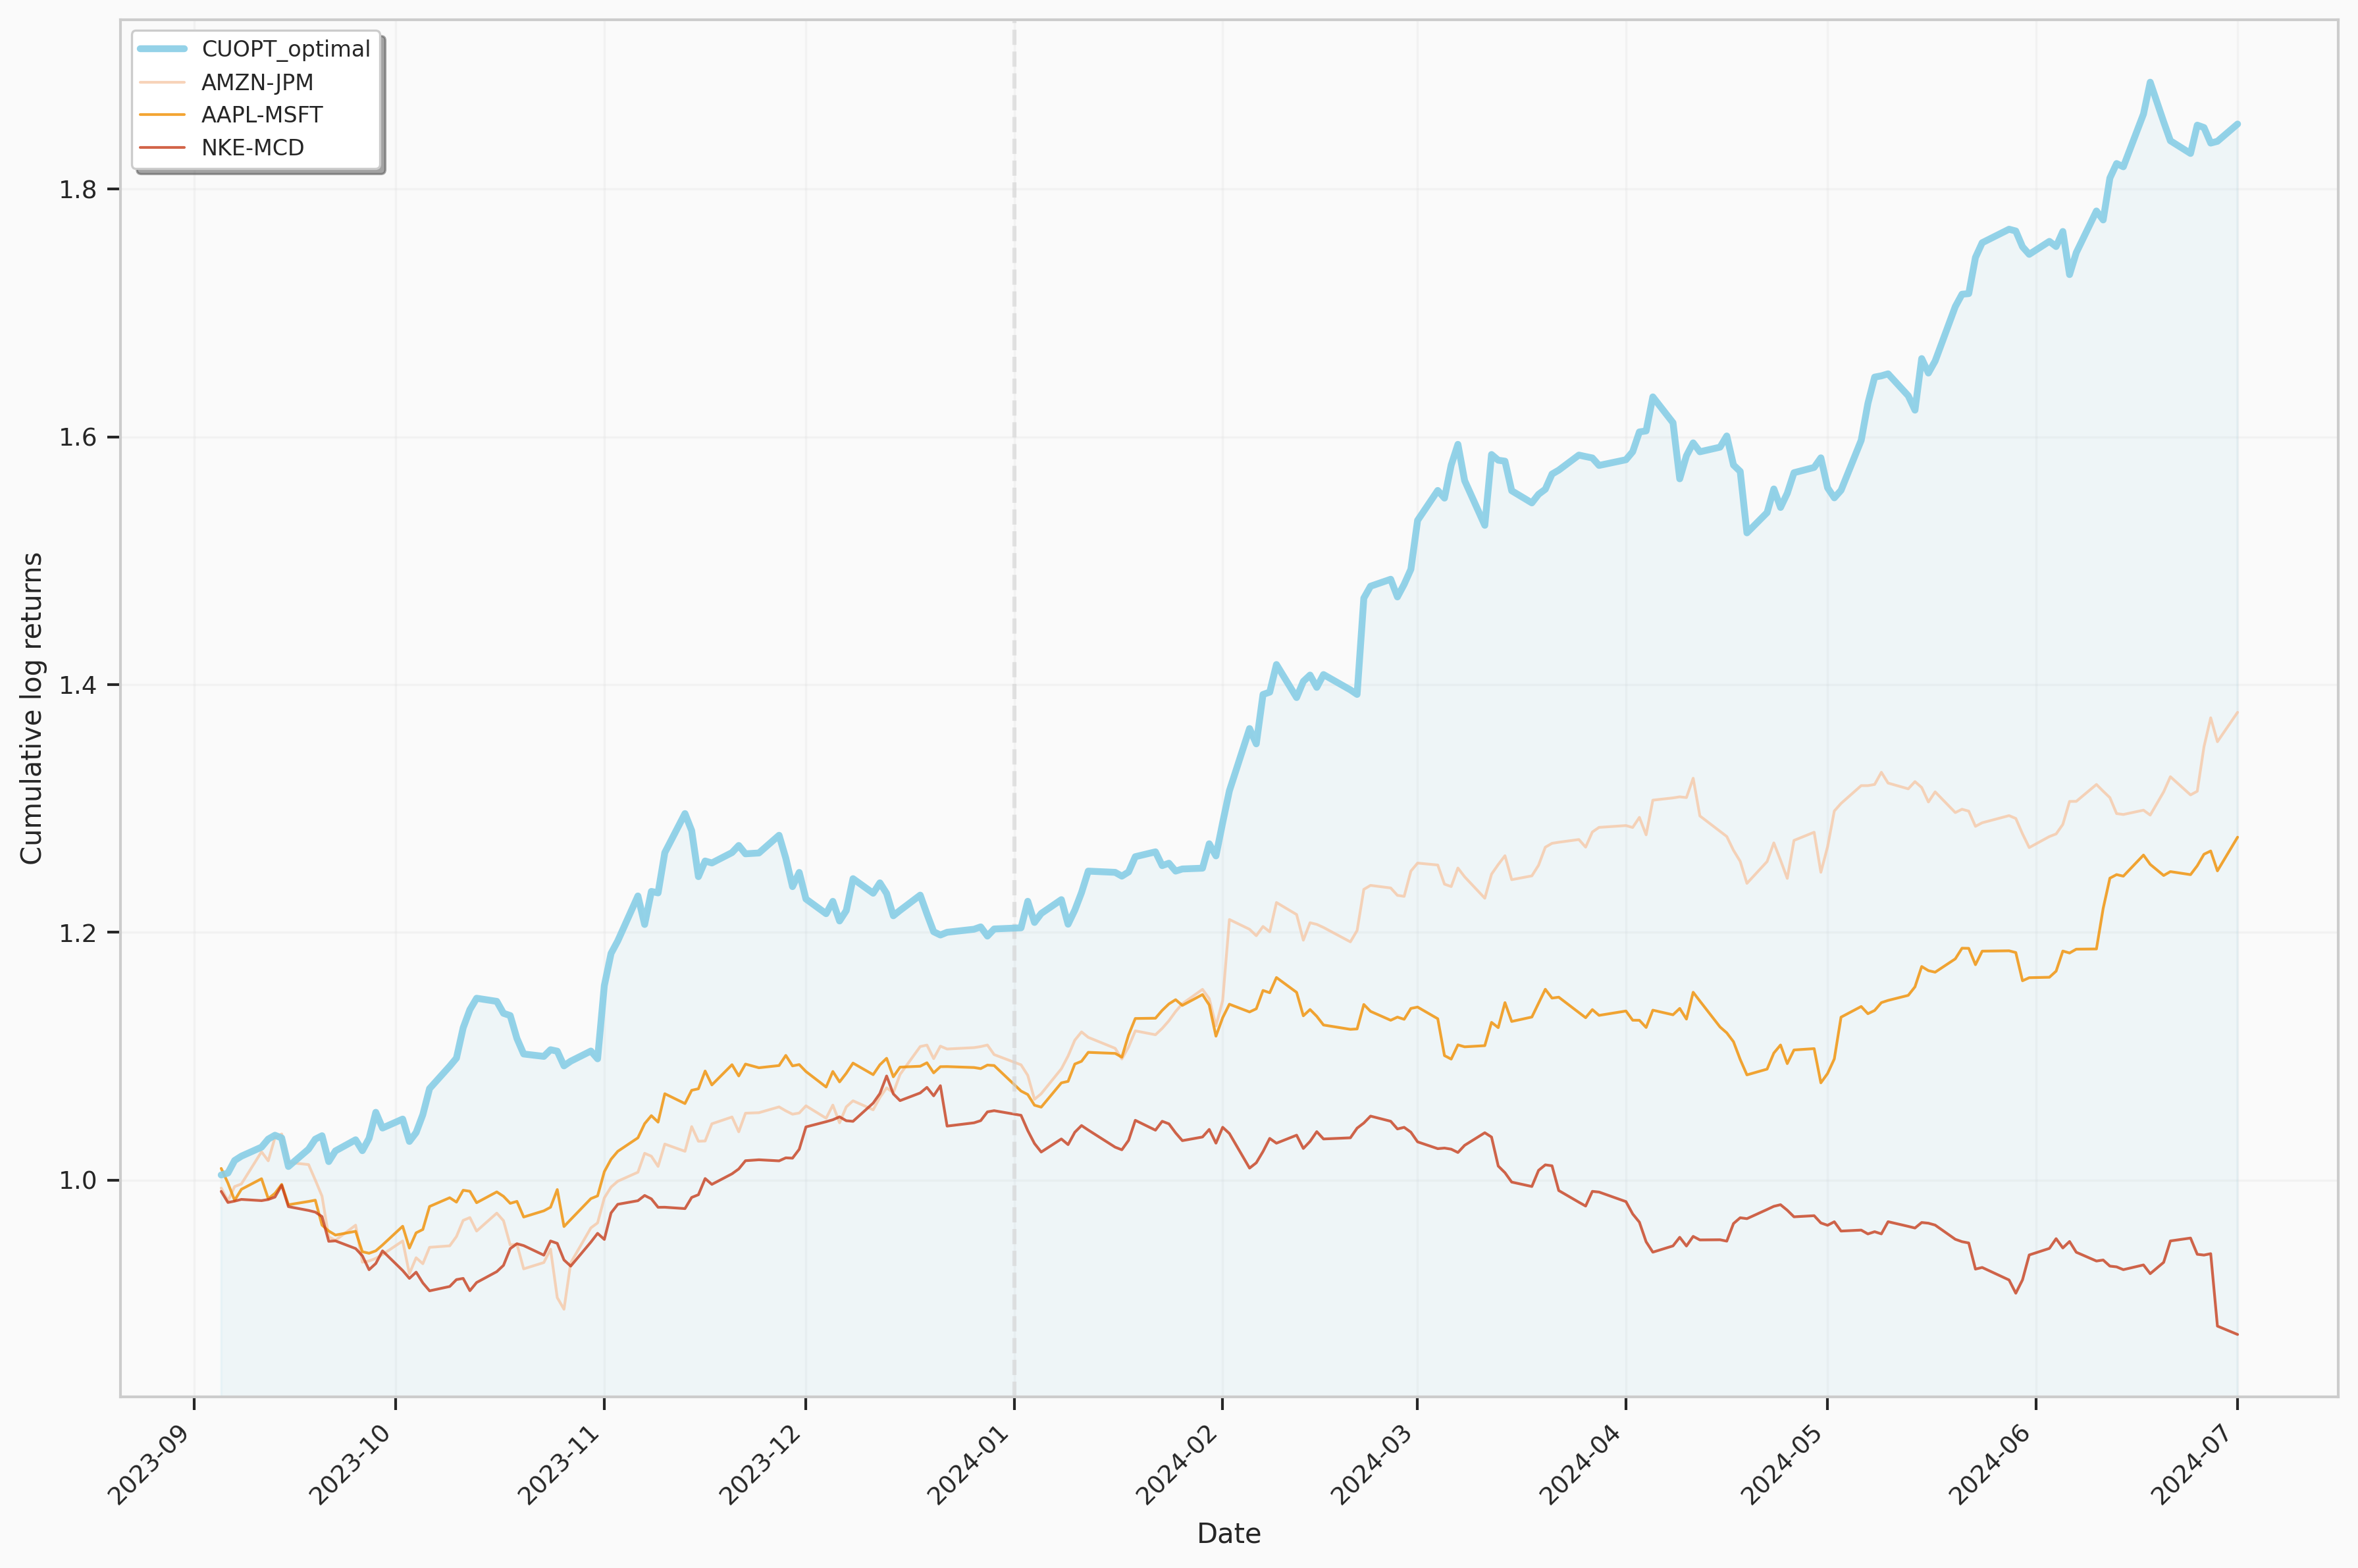

In [15]:
from cufolio import backtest

# (Optional) Compare results between optimized portfolio and user-defined portfolios
portfolios_dict = {'AMZN-JPM':({'AMZN': 0.72, 'JPM': 0.18}, 0.1),\
                   'AAPL-MSFT': ({'AAPL': 0.29, 'MSFT': 0.61}, 0.1),\
                   'NKE-MCD': ({'MCD': 0.65, 'NKE': 0.25}, 0.1)}

benchmark_portfolios = cvar_utils.generate_user_input_portfolios(portfolios_dict, test_returns_dict)

# Uncomment the following lineto use equal-weight benchmark portfolio
# benchmark_portfolios = None 

# Set cut-off date for backtest visualization
cut_off_date = regime_dict["range"][1]

# Create backtester and run backtest
backtester = backtest.portfolio_backtester(gpu_portfolio, test_returns_dict, risk_free, test_method, benchmark_portfolios = benchmark_portfolios)

backtest_result,_ = backtester.backtest_against_benchmarks(plot_returns=True, cut_off_date=cut_off_date)

backtest_result

Combined plot saved: ../results/backtest/combined_cuopt_optimal_historical_analysis.png


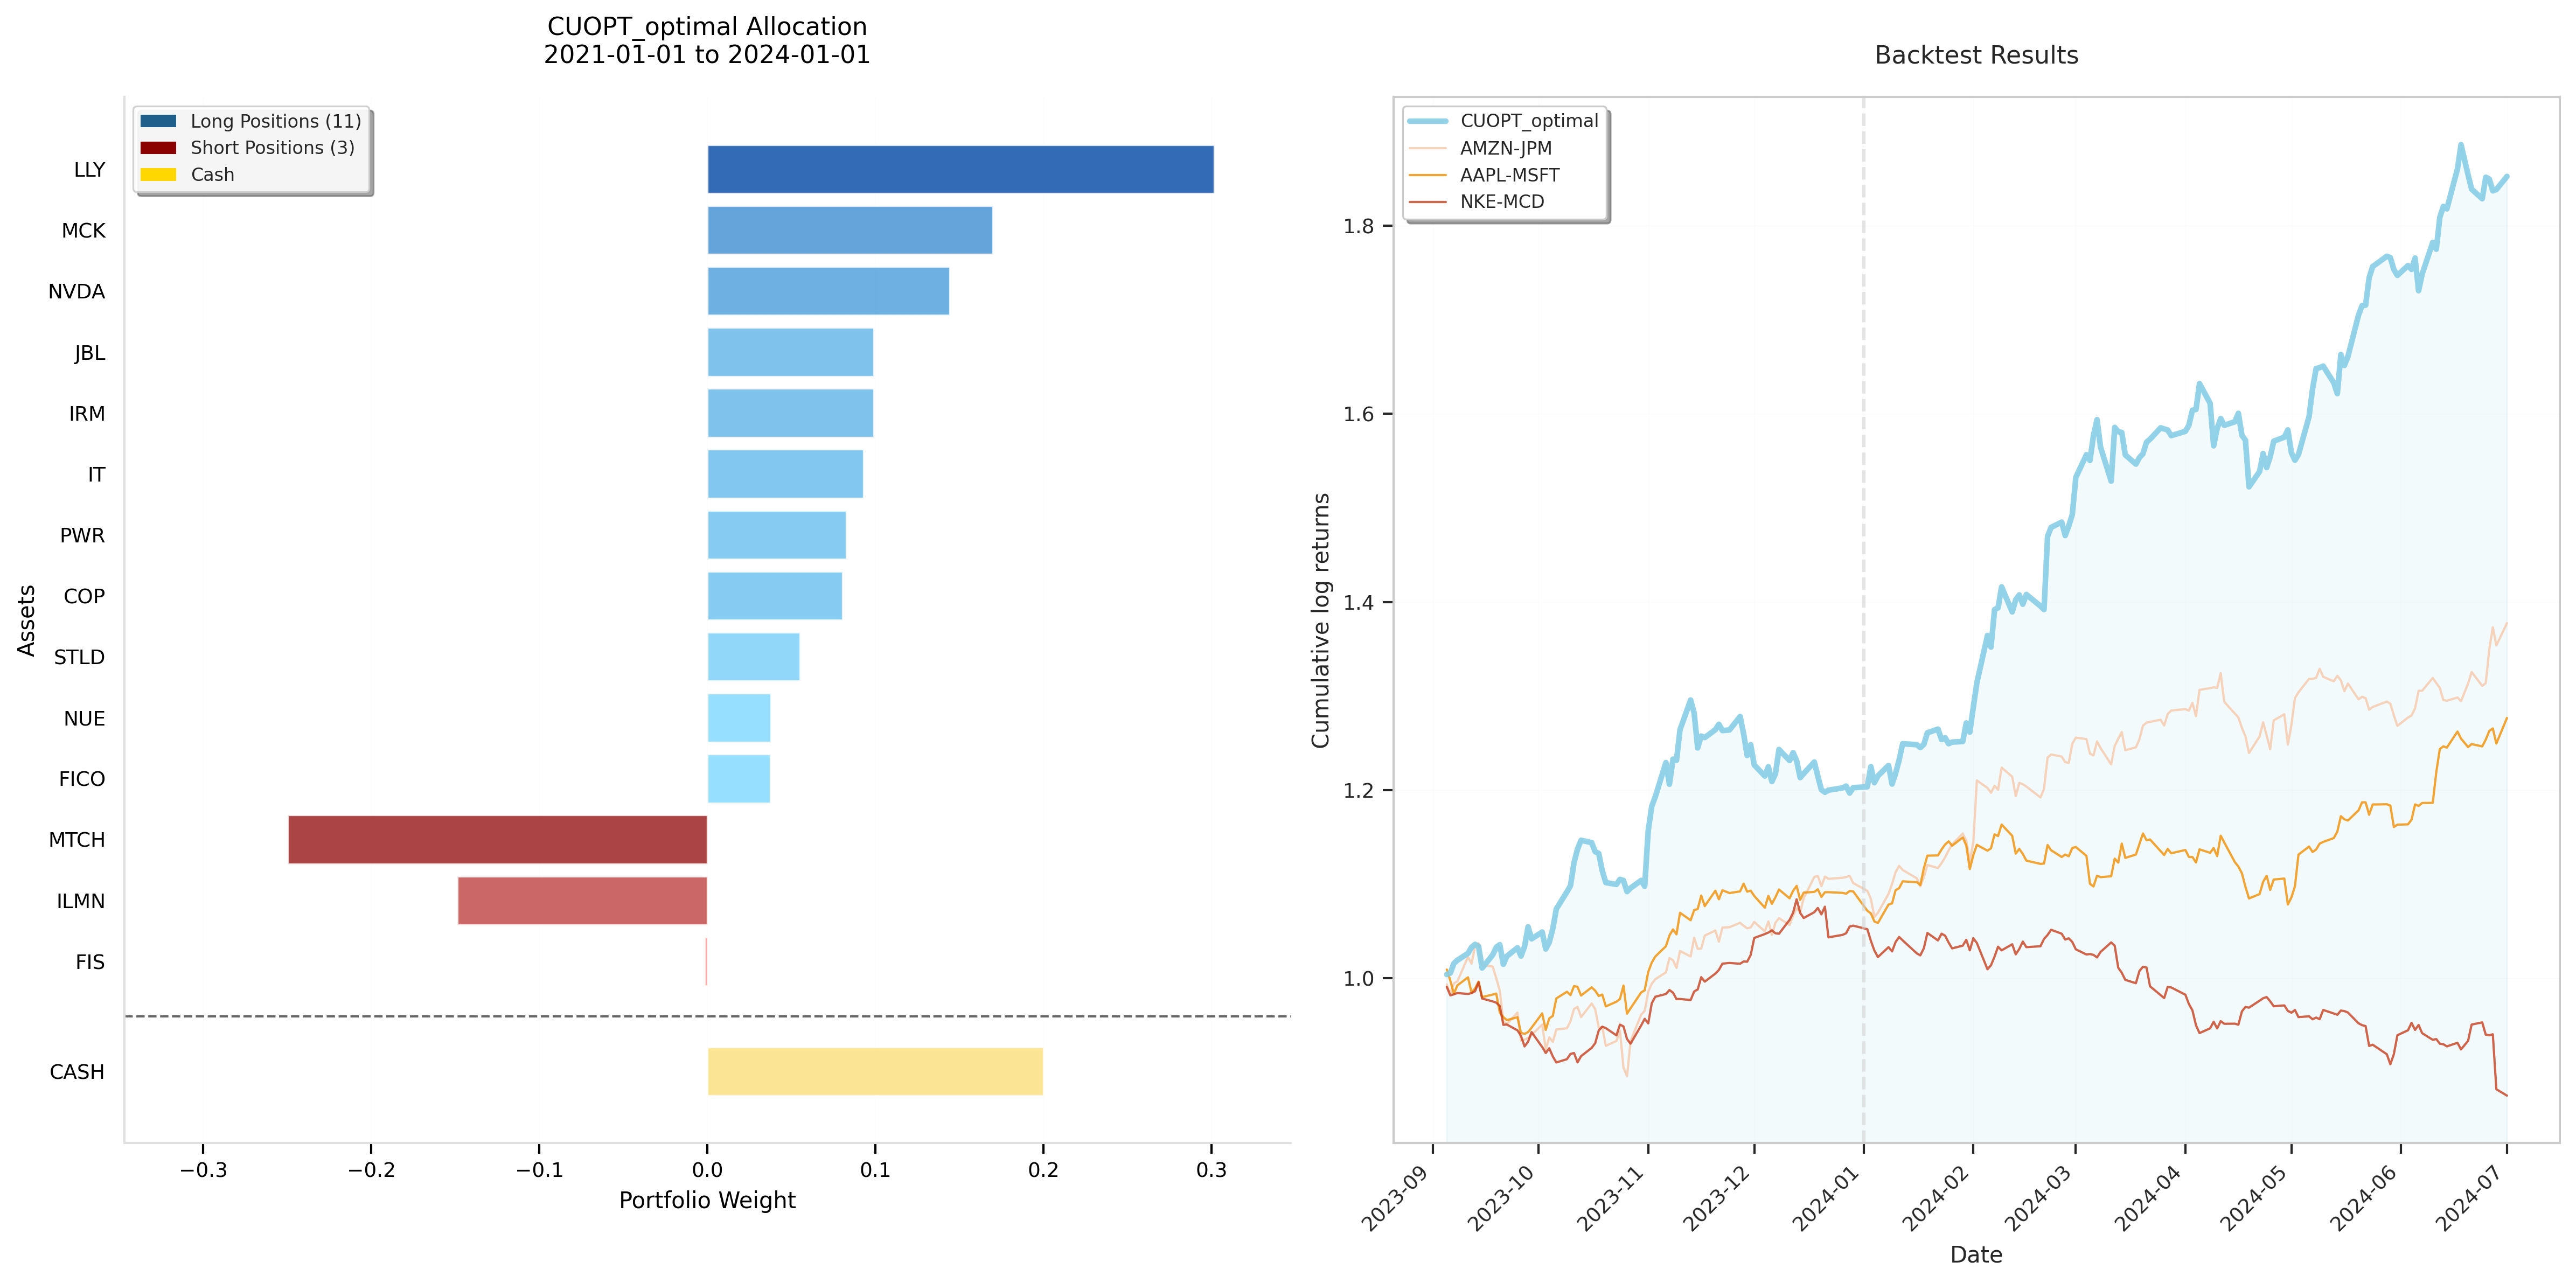

In [16]:
# Plot portfolio and backtest results side by side
utils.portfolio_plot_with_backtest(portfolio=gpu_portfolio, \
                                   backtester=backtester, \
                                   cut_off_date=cut_off_date, \
                                   backtest_plot_title="Backtest Results", \
                                   save_plot = True, \
                                   results_dir = "../results/backtest")

## 6. GPU vs. CPU: Comparison over Different Regimes
<a id='gpu-vs-cpu-comparison-over-different-regimes'></a>

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 Multi-Regime Benchmark</h4>
<code>cvar_utils.optimize_market_regimes</code> generates Mean-CVaR problems iteratively over different regimes from <code>regime_comparison_selected_dict</code>, solves each using all solvers in <code>solver_settings_list</code>, and returns a results dataframe — making it easy to compare GPU vs CPU performance across market conditions.
</div> 

In [17]:
# CVaR parameters for regime comparison
regime_comparison_cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality = None,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95,  # CVaR confidence level (alpha)
)

# User inputs for regime comparison
regime_comparison_dataset_name = "sp500"
regime_comparison_num_scen = 5000
regime_comparison_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
regime_comparison_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=regime_comparison_num_scen,
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Prepare output directory and file name
regime_comparison_output_folder = "../results/regime_results"
os.makedirs(regime_comparison_output_folder, exist_ok=True)
regime_comparison_results_csv_path = os.path.join(
    regime_comparison_output_folder,
    f"both_results_{regime_comparison_dataset_name}_{regime_comparison_num_scen}.csv"
)

# Regime settings (customize as needed)
regime_comparison_selected_dict = {
    "pre_crisis"                  : ("2005-01-01", "2007-10-01"),
    "crisis"                      : ("2007-10-01", "2009-04-01"),
    # "post_crisis"                 : ("2009-06-30", "2014-06-30"),
    # "oil_price_crash"             : ("2014-06-01", "2016-03-01"),
    # "FAANG_surge"                 : ("2015-01-01", "2021-01-01"),
    # "covid"                       : ("2020-01-01", "2023-01-01"),
    # "recent"                      : ("2022-01-01", "2024-07-01")
}

# List of solvers to compare - any supported solver on CVXPY can be used.
solver_settings_list = [
    {"solver": cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4}, 
    {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP", "optimality": 1e-4}
]

regime_comparison_dataset_path = f"../data/stock_data/{regime_comparison_dataset_name}.csv"

# Run CPU vs. GPU comparison across selected regimes
regime_comparison_results_df = utils.optimize_market_regimes(
    input_file_name=regime_comparison_dataset_path,
    returns_compute_settings=regime_comparison_returns_compute_settings,
    scenario_generation_settings=regime_comparison_scenario_generation_settings,
    all_regimes=regime_comparison_selected_dict,
    params=regime_comparison_cvar_params,
    solver_settings_list=solver_settings_list,
    results_csv_file_name=regime_comparison_results_csv_path
)


Processing Regime: pre_crisis

--- Testing Solver: CLARABEL ---

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              pre_crisis
Time Period:         2005-01-01 to 2007-10-01
Scenarios:           5,000
Assets:              387
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.003241 (0.3241%)
CVaR (95%):          0.027443 (2.7443%)
Objective Value:     -0.001927

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.2733 seconds
CVXPY API Overhead:  0.1425 seconds
Solve Time:          13.1048 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2005-01-01 to 2007-10-01

LONG POSITIONS (14 assets)
-------------------------
DLR         0.207 ( 20.65%)
MNST        0.159 ( 15.92%)
AAPL        0.145 ( 14.45%)
ISRG        0.119 ( 11.91%)
ILMN        0.1

In [18]:
# Display regime comparison results
regime_comparison_results_df

,regime,CLARABEL-obj,CLARABEL-solve_time,CLARABEL-return,CLARABEL-CVaR,CLARABEL-optimal_portfolio,CUOPT-obj,CUOPT-solve_time,CUOPT-return,CUOPT-CVaR,CUOPT-optimal_portfolio
0,pre_crisis,-0.001927,13.104814,0.003241,0.027443,"({'AAPL': 0.1445273866976903, 'AMD': -0.047425...",-0.001930,0.240845,0.003246,0.027470,"({'AAPL': 0.14706239673293303, 'AMD': -0.04792..."
1,crisis,-0.003780,12.438955,0.004962,0.059865,"({'AIG': -0.1170967539783796, 'AZO': 0.3650552...",-0.003778,0.539331,0.004958,0.059763,"({'AIG': -0.1174663908419417, 'AZO': 0.3658741..."


In [19]:
# Show the speed-up ratio of CPU solvers vs cuOpt GPU LP solver 
regime_comparison_results_df.index = regime_comparison_results_df['regime']
speed_comparison_df = regime_comparison_results_df['CLARABEL-solve_time'] / regime_comparison_results_df['CUOPT-solve_time'] # CPU solve time / GPU solve time
speed_comparison_df

regime
pre_crisis    54.411900
crisis        23.063664
dtype: float64

---

<a id='appendix'></a>
## 7. Appendix

### 7.1 Optional: Parameter Constraints

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Faster Iteration with CVXPY Parameters</h4>
Optionally define weight and cash constraints as CVXPY parameters for faster iteration — update bounds without rebuilding the entire problem.
<br><br>
By default, <code>cvar_optimizer.py</code> uses variable bounds:
<pre><code>self.w = cp.Variable(num_assets, name="weights", bounds=[self.params.w_min, self.params.w_max])</code></pre>
because cuOpt LP solver is empirically faster when constraints are set as variable bounds.
</div> 

In [20]:
# Instantiate CVaR optimization problem for the S&P 500 example
api_settings = ApiSettings(
    api="cvxpy",  # "cvxpy" or "cuopt_python"
    weight_constraints_type="parameter",  # "parameter" or "bounds" (CVXPY only)
    cash_constraints_type="parameter",  # "parameter" or "bounds" (CVXPY only)
)
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=api_settings
)

# Solve on GPU
gpu_solver_settings = {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP"} 
gpu_results, gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)



CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              387
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002527 (0.2527%)
CVaR (95%):          0.025691 (2.5691%)
Objective Value:     -0.001410

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.3095 seconds
CVXPY API Overhead:  0.0761 seconds
Solve Time:          0.3808 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.302 ( 30.17%)
MCK         0.170 ( 16.99%)
NVDA        0.144 ( 14.41%)
JBL         0.099 (  9.91%)
IRM         0.099 (  9.89%)
IT          0.093 (  9.29%)
PWR         0.083 (  8.27%)
COP  

### 7.2 Optional: cuOpt Python API

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Native cuOpt API</h4>
Instead of using CVXPY, you can build the problem directly with the cuOpt native Python API by choosing <code>api_settings</code>.
</div>


In [21]:
# Instantiate CVaR optimization problem using cuOpt Python API
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=ApiSettings(api="cuopt_python")
)

# Solver settings for cuOpt Python API
cuopt_settings = {"log_to_console":True, "presolve": 0, "method": 1}

# Solve using cuOpt Python API
cuopt_gpu_results, cuopt_gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=cuopt_settings)


cuOpt PROBLEM SETUP COMPLETED
Variables: 387 weights + 1 cash + 10000 auxiliary + 1 threshold
           + 774 leverage decomposition
Constraints: Budget + 10000 CVaR scenarios + additional constraints
Problem Type: LP
Setting parameter log_to_console to true
Setting parameter presolve to 0
Setting parameter method to 1
cuOpt version: 26.4.0, git hash: d9b7c96a, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480C, threads (physical/logical): 112/224, RAM: 1663.97 GiB
CUDA 13.0, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: ffffffd4ffffffc2ffffffaa50-6132-3b50

Solving a problem with 10389 constraints, 11163 variables (0 integers), and 3892323 nonzeros
Problem scaling:
Objective coefficents range:          [6e-07, 4e-02]
Constraint matrix coefficients range: [3e-09, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Objective offset 0

<a id="efficient-frontier"></a>
## 8. Efficient Frontier

The efficient frontier is the Pareto-optimal curve representing the best attainable trade-off between expected return and risk. Every point on this frontier dominates all other feasible portfolios by offering a higher return for the same risk (or lower risk for the same return), making it the gold standard for comparing asset allocation strategies.

Constructing this frontier requires solving hundreds of portfolio optimization problems, typically by sweeping across different risk-aversion parameters or target return levels. This computational intensity makes solver performance pivotal, as each speedup compounds. Leveraging a GPU solver like cuOpt dramatically accelerates this iterative workflow, significantly cutting runtime compared to CPU-only approaches.

In this notebook, we generate the efficient frontier by iterating over different risk aversion levels. We can compare the overall performance using cuOpt GPU solver vs. a CPU solver and see how the speed-up on a single optimization problem multiplies in one of the advanced, practical workflows. 

In [ ]:
# Define CVaR optimization parameters for Efficient Frontier (EF) construction
ef_cvar_params = CvarParameters(
    w_min=0.0, w_max=1.0,             # Asset weight bounds (no shorting)
    c_min=0.0, c_max=0.0,             # Cash holdings bounds (no cash allocation)
    L_tar=1.0,                        # Leverage target (fully invested; sum of weights equals 1 for long only)
    T_tar=None,                       # No turnover constraint
    cvar_limit=None,                  # Maximum CVaR (unconstrained)
    risk_aversion=1,                  # Base risk aversion (varied to generate the efficient frontier)
    confidence=0.95,                  # CVaR confidence level
)

In [ ]:
# User inputs for efficient frontier example
ef_dataset_name = "sp500"

# Get date range and file path
ef_regime = "recent"
ef_range = ('2022-01-01', '2024-07-01')
ef_regime_dict = {"name": ef_regime, "range": ef_range}
ef_dataset_path = f"../data/stock_data/{ef_dataset_name}.csv"

# define the settings for computing returns and scenario generation
ef_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
ef_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Compute returns for the efficient frontier
ef_returns_dict = utils.calculate_returns(ef_dataset_path, ef_regime_dict, ef_returns_compute_settings)
ef_returns_dict = cvar_utils.generate_cvar_data(ef_returns_dict, ef_scenario_generation_settings)

### Using `create_efficient_frontier`

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 API Overview</h4>
<code>create_efficient_frontier</code> sweeps risk-aversion levels, solves the CVaR problem at each point, and returns the frontier plot together with a DataFrame of optimal portfolios.
<ul>
<li><strong>Core inputs</strong>: <code>input_file_name</code>, <code>regime_dict</code>, <code>return_type</code>, <code>cvar_params</code>, and a <code>solver_settings</code> dict</li>
<li><strong>Risk-aversion sweep</strong>: <code>ra_num</code>, <code>min_risk_aversion</code> / <code>max_risk_aversion</code> (logarithmic bounds)</li>
<li><strong>Portfolio overlays</strong>: <code>custom_portfolios_dict</code> and <code>benchmark_portfolios</code> to annotate the plot</li>
<li><strong>Discrete comparisons</strong> (optional): <code>show_discretized_portfolios</code> + <code>discretization_params</code> for exhaustive combinatorial evaluation</li>
<li><strong>Presentation</strong>: <code>notional</code>, <code>style</code>, <code>color_scheme</code>, <code>dpi</code>, <code>save_path</code></li>
<li><strong>Outputs</strong>: <code>(results_df, fig, ax)</code> for downstream analysis or custom visuals</li>
</ul>
The next cell demonstrates a baseline call. We also overlay a custom portfolio to show that, at the same risk level, the optimized portfolio achieves significantly higher returns.
</div>

In [ ]:
# Efficient Frontier (EF) Settings

# Optional: Define custom portfolios to display on the EF plot
ef_custom_portfolios_dict = {
    "AAPL-LLY-MSFT portfolio": ({"AAPL": 0.3, "LLY": 0.2, "MSFT": 0.5}, 0.0) # ({asset_weights_dict}, cash_holding_float)
}

ef_plot_title = f"Efficient Frontier Plot – {ef_dataset_name} ({ef_regime})"
ef_output_folder = "../results/EF_results/" # Folder to save EF results
ef_results_csv_path = os.path.join(ef_output_folder, "EF_results.csv")
ef_plot_png_path = os.path.join(ef_output_folder, "EF_plot.png")

# Range for risk aversion parameter (lambda_risk)
ef_min_risk_aversion_exp = -3         # Corresponds to 1e-3 (high risk appetite)
ef_max_risk_aversion_exp = 1          # Corresponds to 1e1 = 10 (risk-averse)
ef_risk_aversion_steps = 30           # Number of riskaversion levels for a smoother EF

# Prepare output directory
os.makedirs(ef_output_folder, exist_ok=True)

Computing efficient frontier with 30 portfolios...
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1


Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
   ✓ Completed 10/30 portfolios
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console

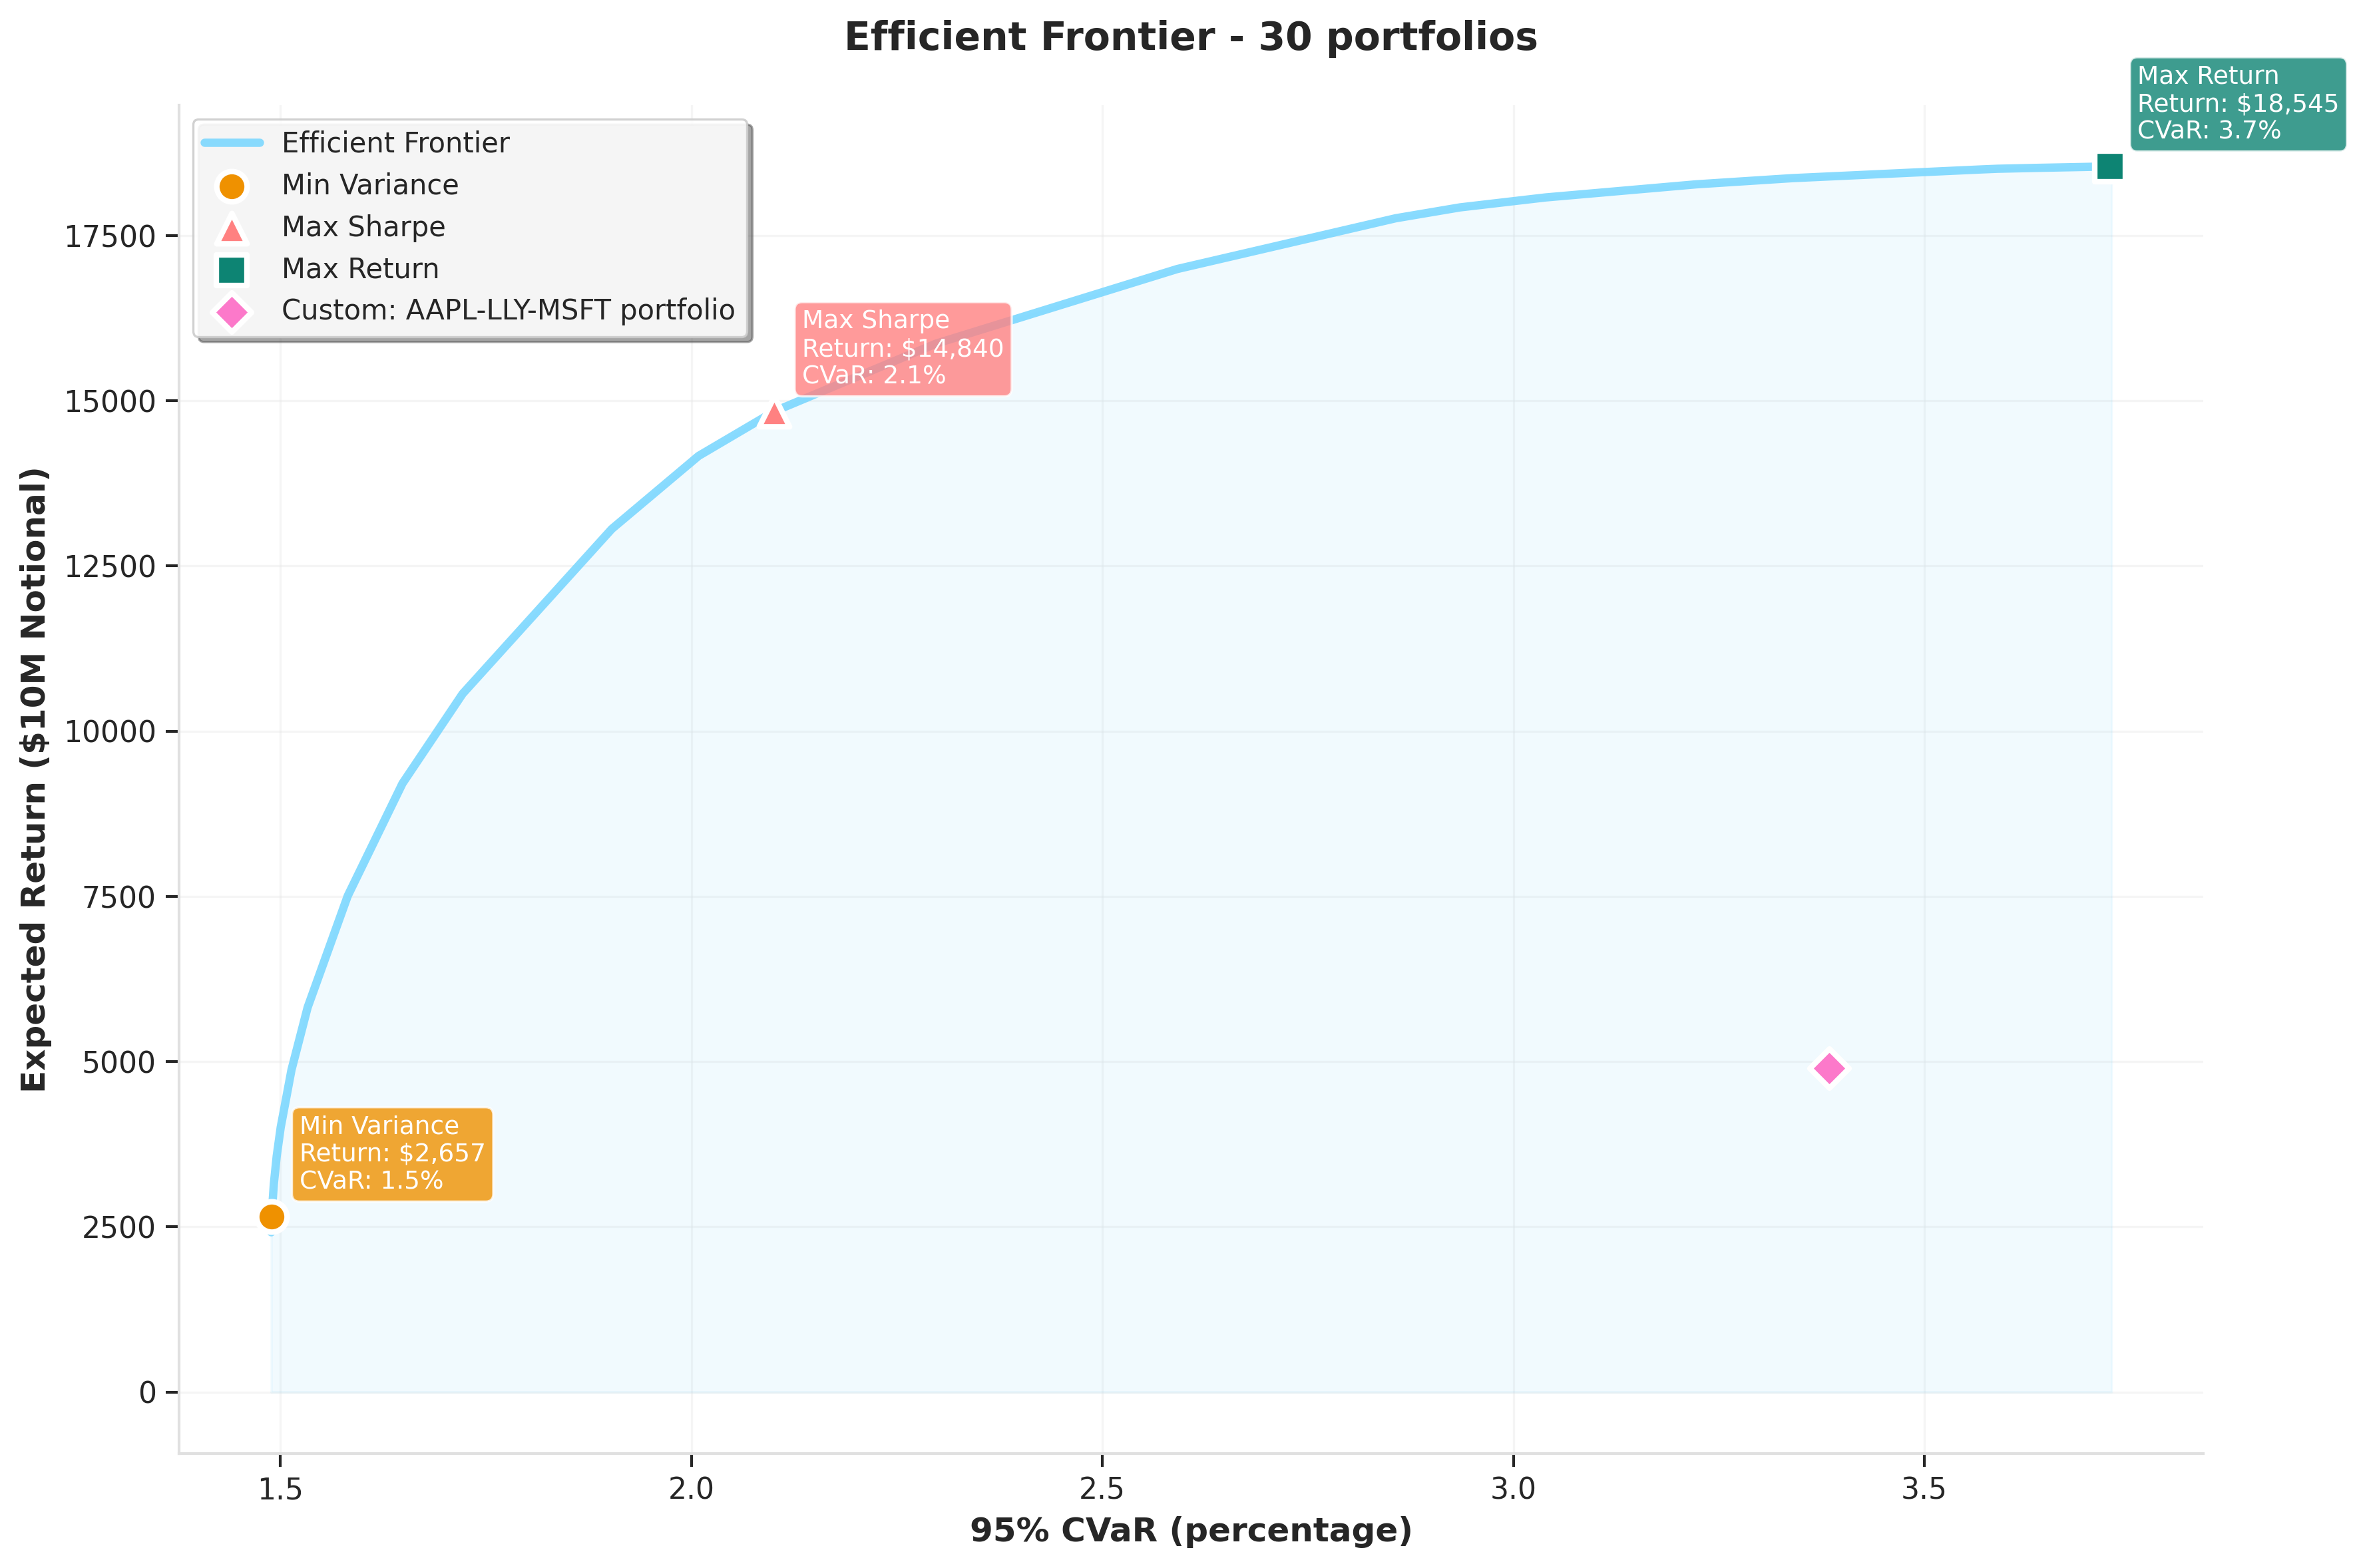

Efficient frontier analysis complete!


In [ ]:
# Define solver settings
ef_solver_settings = {"solver": cp.CUOPT, "verbose": False, 'solver_method': 'PDLP'}

# Create efficient frontier and generate the plot
results_df, fig, ax = cvar_utils.create_efficient_frontier(
    ef_returns_dict,
    ef_cvar_params,
    ef_solver_settings,
    custom_portfolios_dict = ef_custom_portfolios_dict,
    ra_num = ef_risk_aversion_steps,
    min_risk_aversion = ef_min_risk_aversion_exp,
    max_risk_aversion = ef_max_risk_aversion_exp,
    save_path = None,
    show_discretized_portfolios = False, #optional to turn on, but very time consuming
    #discretization_params={
    #    "weight_discretization": 50,
    #    "min_weight": ef_cvar_params.w_min,
    #    "max_weight": ef_cvar_params.w_max
    #},
    print_portfolio_results = False,
    show_plot = True
)

In [6]:
# Display results
results_df

,regime,solver,solve time,return,CVaR,obj,risk_aversion,variance,volatility,sharpe
0,recent,CUOPT,0.272733,0.000242,0.014890,0.148655,10.000000,0.000054,0.007325,0.524004
1,recent,CUOPT,0.194469,0.000246,0.014890,0.108140,7.278954,0.000054,0.007322,0.533812
2,recent,CUOPT,0.187210,0.000250,0.014890,0.078643,5.298317,0.000054,0.007320,0.541378
3,recent,CUOPT,0.188212,0.000257,0.014892,0.057177,3.856620,0.000054,0.007319,0.556612
4,recent,CUOPT,0.180281,0.000266,0.014895,0.041548,2.807216,0.000054,0.007319,0.576315
5,recent,CUOPT,0.186138,0.000283,0.014904,0.030170,2.043360,0.000054,0.007326,0.613517
6,recent,CUOPT,0.192251,0.000316,0.014922,0.021879,1.487352,0.000054,0.007350,0.681690
7,recent,CUOPT,0.201109,0.000357,0.014956,0.015835,1.082637,0.000054,0.007375,0.768576
8,recent,CUOPT,0.211997,0.000401,0.015005,0.011424,0.788046,0.000055,0.007401,0.859538
9,recent,CUOPT,0.212806,0.000487,0.015136,0.008195,0.573615,0.000056,0.007465,1.036552


<a id="rebalancing-strategies"></a>
## 9. Rebalancing Strategies

This notebook demonstrates dynamic portfolio rebalancing strategies using the core Mean-CVaR optimization module. Rebalancing adapts portfolio weights in response to market changes, aiming to maintain optimal performance while accounting for transaction costs and turnover constraints. In this example, we implement a simple transaction cost model: transaction_cost = transaction_cost_factor * turnover, with turnover $=\lVert w-w_{pre} \rVert_1$. 

We compare two rebalancing triggers:
- [Percentage change](#percentage-change): Reoptimize when portfolio value drops below a threshold.
- [Drift from optimal](#drift-from-optimal): Reoptimize when current weights deviate from optimal weights by a specified norm.

Both strategies are benchmarked against a buy-and-hold baseline, and we may evaluate performance using GPU (cuOpt) vs. CPU solvers.


In [ ]:
import os
import numpy as np
import cvxpy as cp

from cufolio import rebalance
from cufolio.cvar_parameters import CvarParameters
from cufolio.settings import (
    KDESettings,
    ReturnsComputeSettings,
    ScenarioGenerationSettings,
)

In [ ]:
# Global data settings.
# Define dataset paths and common parameters.
sp500_dataset_name = "sp500"
sp500_dataset_directory = f"../data/stock_data/{sp500_dataset_name}.csv"

# Define the settings for computing returns and scenario generation
rebal_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
rebal_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

In [3]:
# Define CVaR parameters for rebalancing with transaction costs and turnover constraints.
rebal_tc_cvar_params = CvarParameters(
    w_min=-0.3,
    w_max=0.8,
    c_min=0.1,
    c_max=0.4,
    L_tar=1.6,
    T_tar=0.5,        # Turnover constraint to limit trading activity.
    cvar_limit=None,
    risk_aversion=1,
    confidence=0.95,
)

### Strategy 1: Percentage Change Rebalancing
<a id='percentage-change'></a>

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Trigger Conditions</h4>
Re-optimization is triggered if either condition holds:
<ul>
<li>The percent change from the start to the end of the testing period drops below <code>pct_change_tolerance</code></li>
<li>The cumulative percent change since the <em>last positive</em> backtest period drops below <code>pct_change_tolerance</code></li>
</ul>
Example setup: 21-day (one-month) look-forward window and 252-day (one-year) look-back window for rolling optimization, with cuOpt as the GPU solver.
</div> 


BASELINE (BUY & HOLD) ANALYSIS
Period: 2022-07-01 to 2024-01-01
Strategy: Single optimization at start
Setting parameter log_to_console to false
Setting parameter method to 1

BASELINE COMPLETE
Final portfolio value: $0.90
Total return: -8.27%
Data points collected: 357

DYNAMIC REBALANCING ANALYSIS
Period: 2022-07-01 to 2024-01-01
Strategy: Percentage Change
Threshold: -0.005
Look-forward window: 21 days
Look-back window: 252 days
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-08-02 | Event #1 | Portfolio value: $0.96
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-09-30 | Event #2 | Portfolio value: $1.03
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-11-30 | Event #3 | Portfolio value: $0.99
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-12-30 | Event #4 | Portfolio v

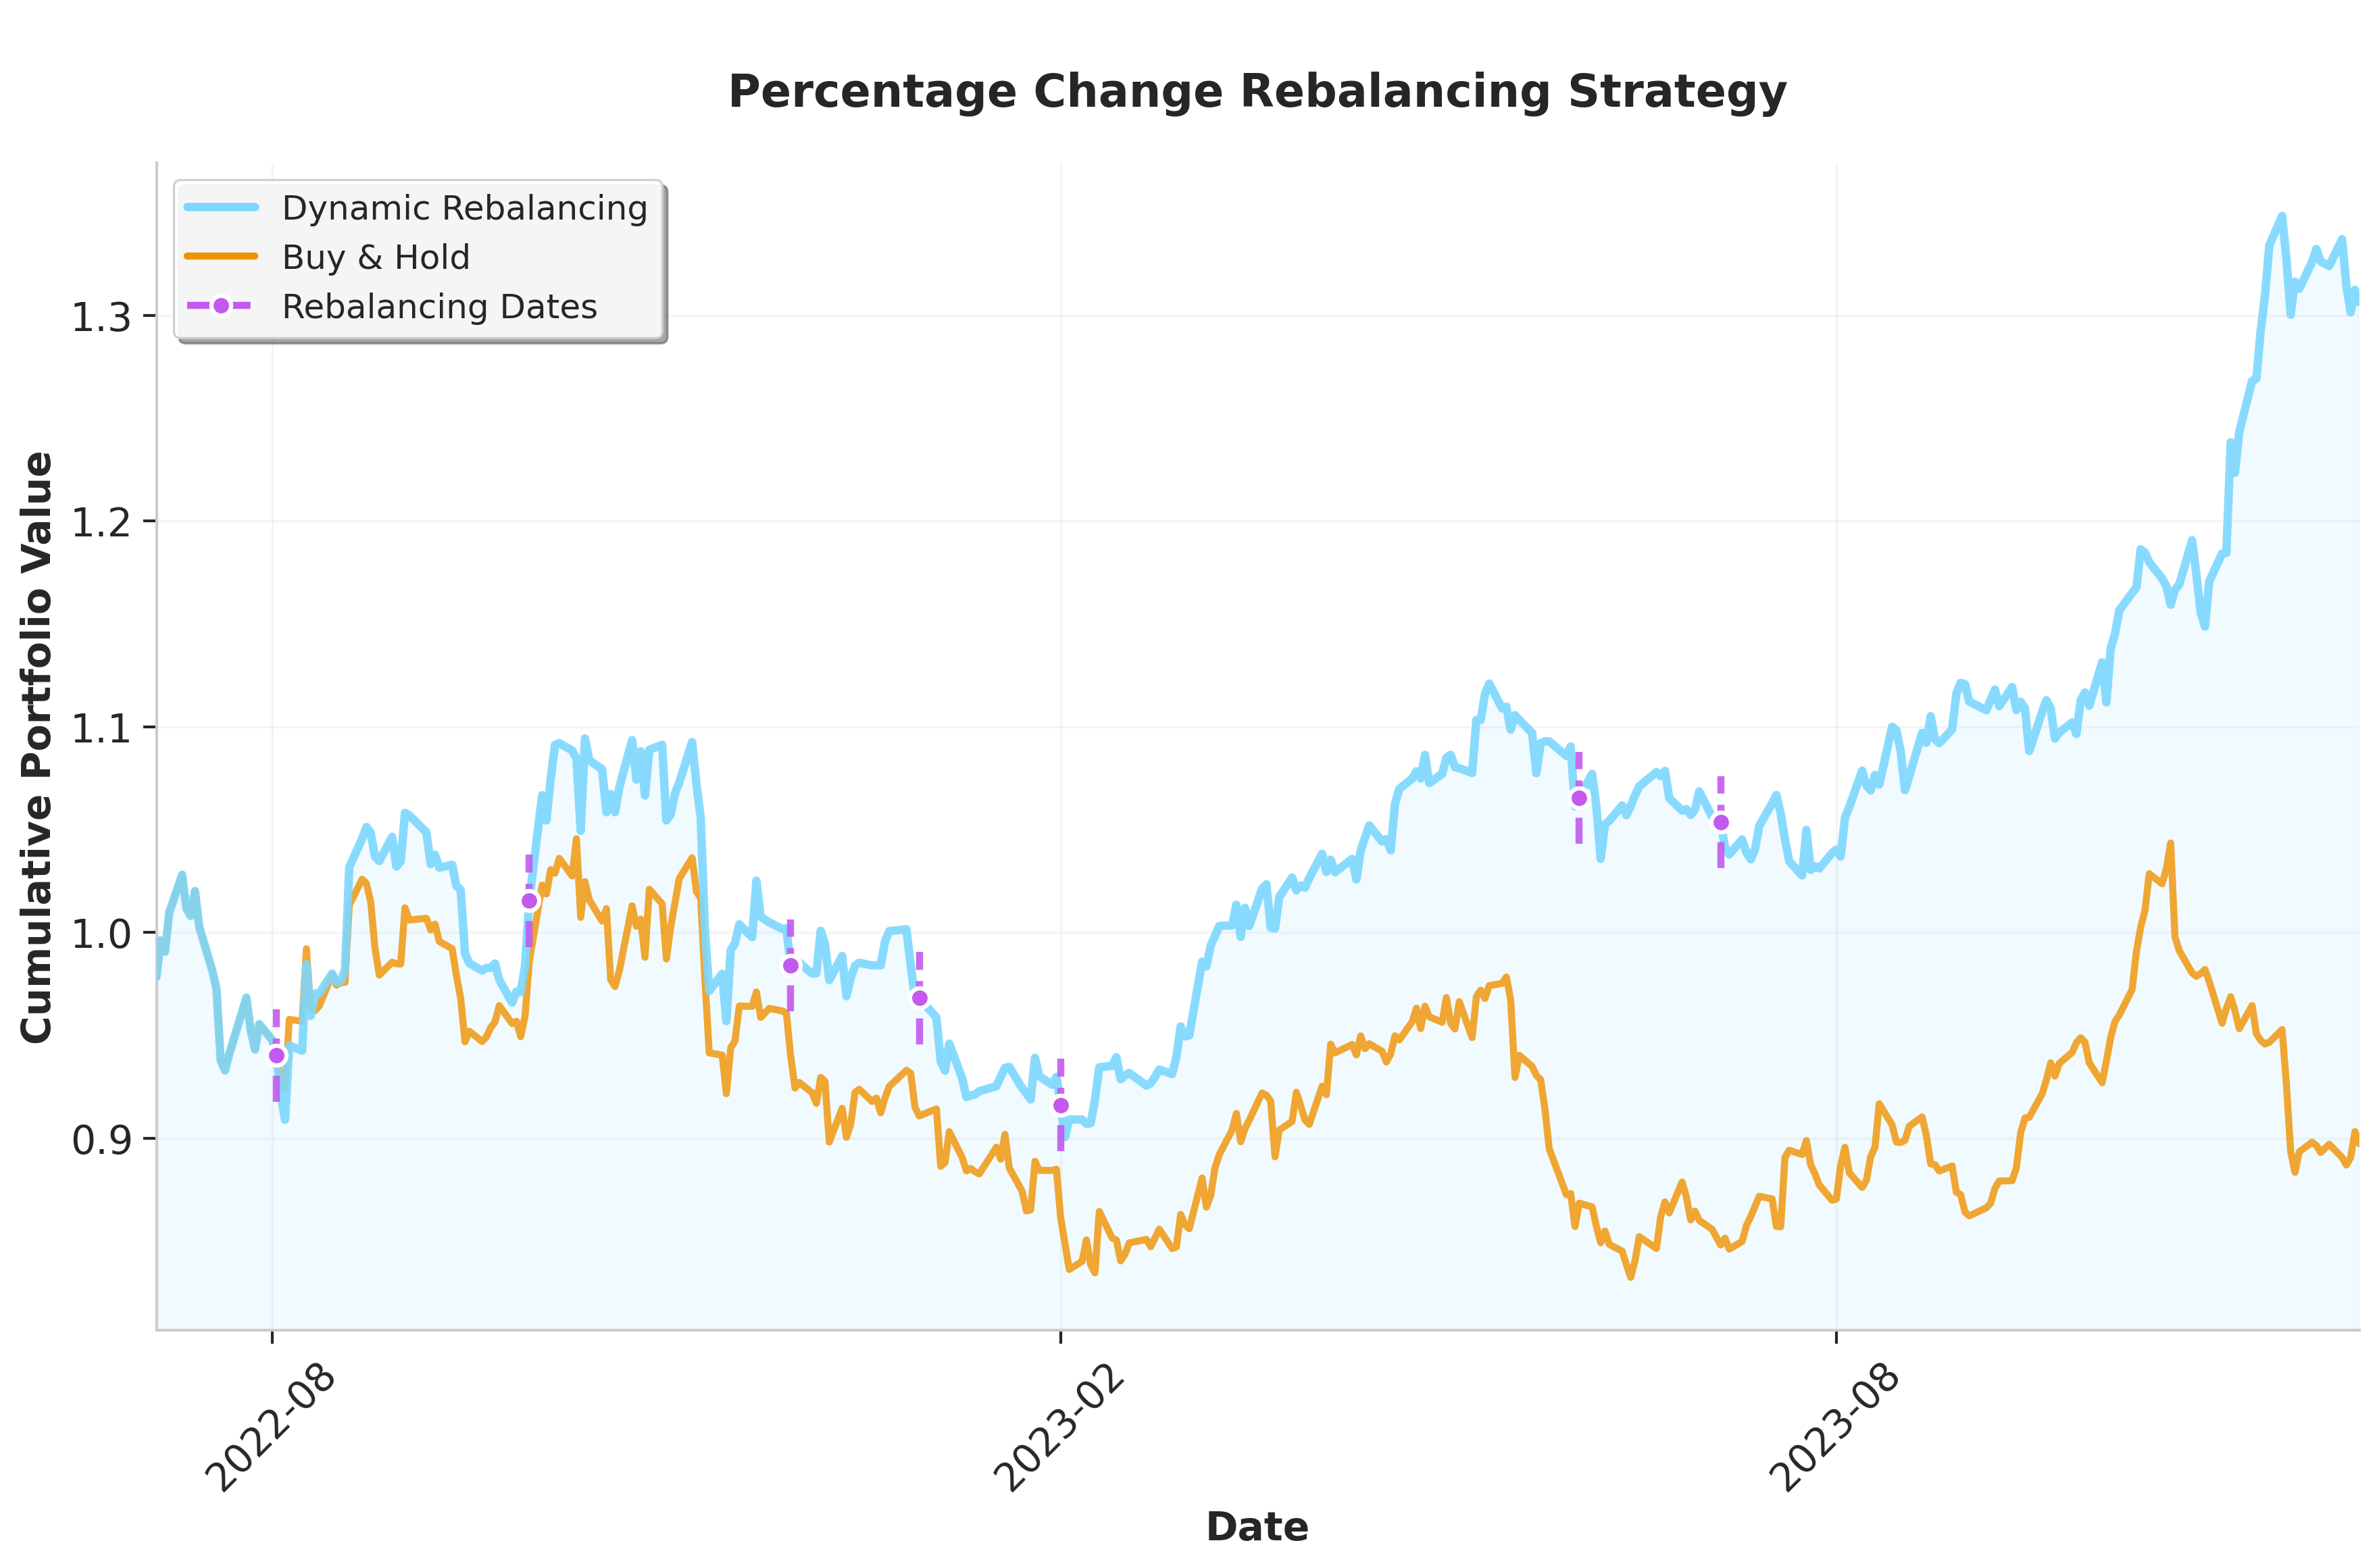

In [6]:
# Trading period and backtesting windows.
selected_rebal_scenario_name = 'rebalancing_trading_period'
rebal_trading_start_date, rebal_trading_end_date = "2022-07-01", "2024-01-01"

rebal_look_back_window = 252       # Historical period for optimization (trading days).
rebal_look_forward_window = 21     # Out-of-sample testing period (trading days).

# Transaction cost parameters
transaction_cost_factor = 0.001

# Reoptimization trigger: percentage change threshold.
percent_change_tolerance = -0.005   # Reoptimize if portfolio value drops by 0.5%.
pct_change_re_optimize_criteria = {"type": "pct_change", "threshold": percent_change_tolerance}

# GPU solver configuration.
solver_settings = {'solver':cp.CUOPT, 'verbose': False, 'solver_method': 'PDLP'}

# Execute portfolio rebalancing with percentage change trigger.
pct_change_rebalancing_obj = rebalance.rebalance_portfolio(
    dataset_directory=sp500_dataset_directory,
    returns_compute_settings = rebal_returns_compute_settings,
    scenario_generation_settings = rebal_scenario_generation_settings,
    trading_start=rebal_trading_start_date,
    trading_end=rebal_trading_end_date,
    look_forward_window=rebal_look_forward_window,
    look_back_window=rebal_look_back_window,
    cvar_params=rebal_tc_cvar_params,
    solver_settings = solver_settings,
    re_optimize_criteria=pct_change_re_optimize_criteria, #specify the re-optimization criteria
    print_opt_result = False
)

# Retrieve and plot optimization results.
pct_change_results_df, pct_change_re_optimize_dates, cumulative_portfolio_value_array = pct_change_rebalancing_obj.re_optimize(
                                                                                                                        transaction_cost_factor = transaction_cost_factor, \
                                                                                                                        plot_results=True, \
                                                                                                                        save_plot = True, \
                                                                                                                        results_dir = "../results/rebalancing_strategies"
                                                                                                                        )

### Strategy 2: Drift from Optimal Portfolio
<a id='drift-from-optimal'></a>

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Drift-Based Trigger</h4>
Over time the portfolio composition drifts from the original optimized allocation. Re-optimization is triggered when:
$$\lVert w_{cur} - w_{opt} \rVert_* > tol,$$
where:
<ul>
<li>$w_{cur}$ = Current portfolio weights</li>
<li>$w_{opt}$ = Optimal portfolio weights</li>
<li>$tol$ = <code>drift_tolerance</code></li>
<li>Norm $*$: 1-norm (absolute differences) or 2-norm (Euclidean distance)</li>
</ul>
</div>

BASELINE (BUY & HOLD) ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Single optimization at start
Setting parameter log_to_console to false
Setting parameter method to 1

BASELINE COMPLETE
Final portfolio value: $0.85
Total return: -13.38%
Data points collected: 420

DYNAMIC REBALANCING ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Drift From Optimal
Threshold: 0.05
Look-forward window: 42 days
Look-back window: 252 days
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-08-31 | Event #1 | Portfolio value: $0.98
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-10-31 | Event #2 | Portfolio value: $0.95


Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-12-30 | Event #3 | Portfolio value: $0.87
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-03-03 | Event #4 | Portfolio value: $0.78
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-05-03 | Event #5 | Portfolio value: $0.86
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-07-05 | Event #6 | Portfolio value: $0.81
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-09-01 | Event #7 | Portfolio value: $0.84
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-11-01 | Event #8 | Portfolio value: $0.89
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2024-01-03 | Event #9 | Portfolio value

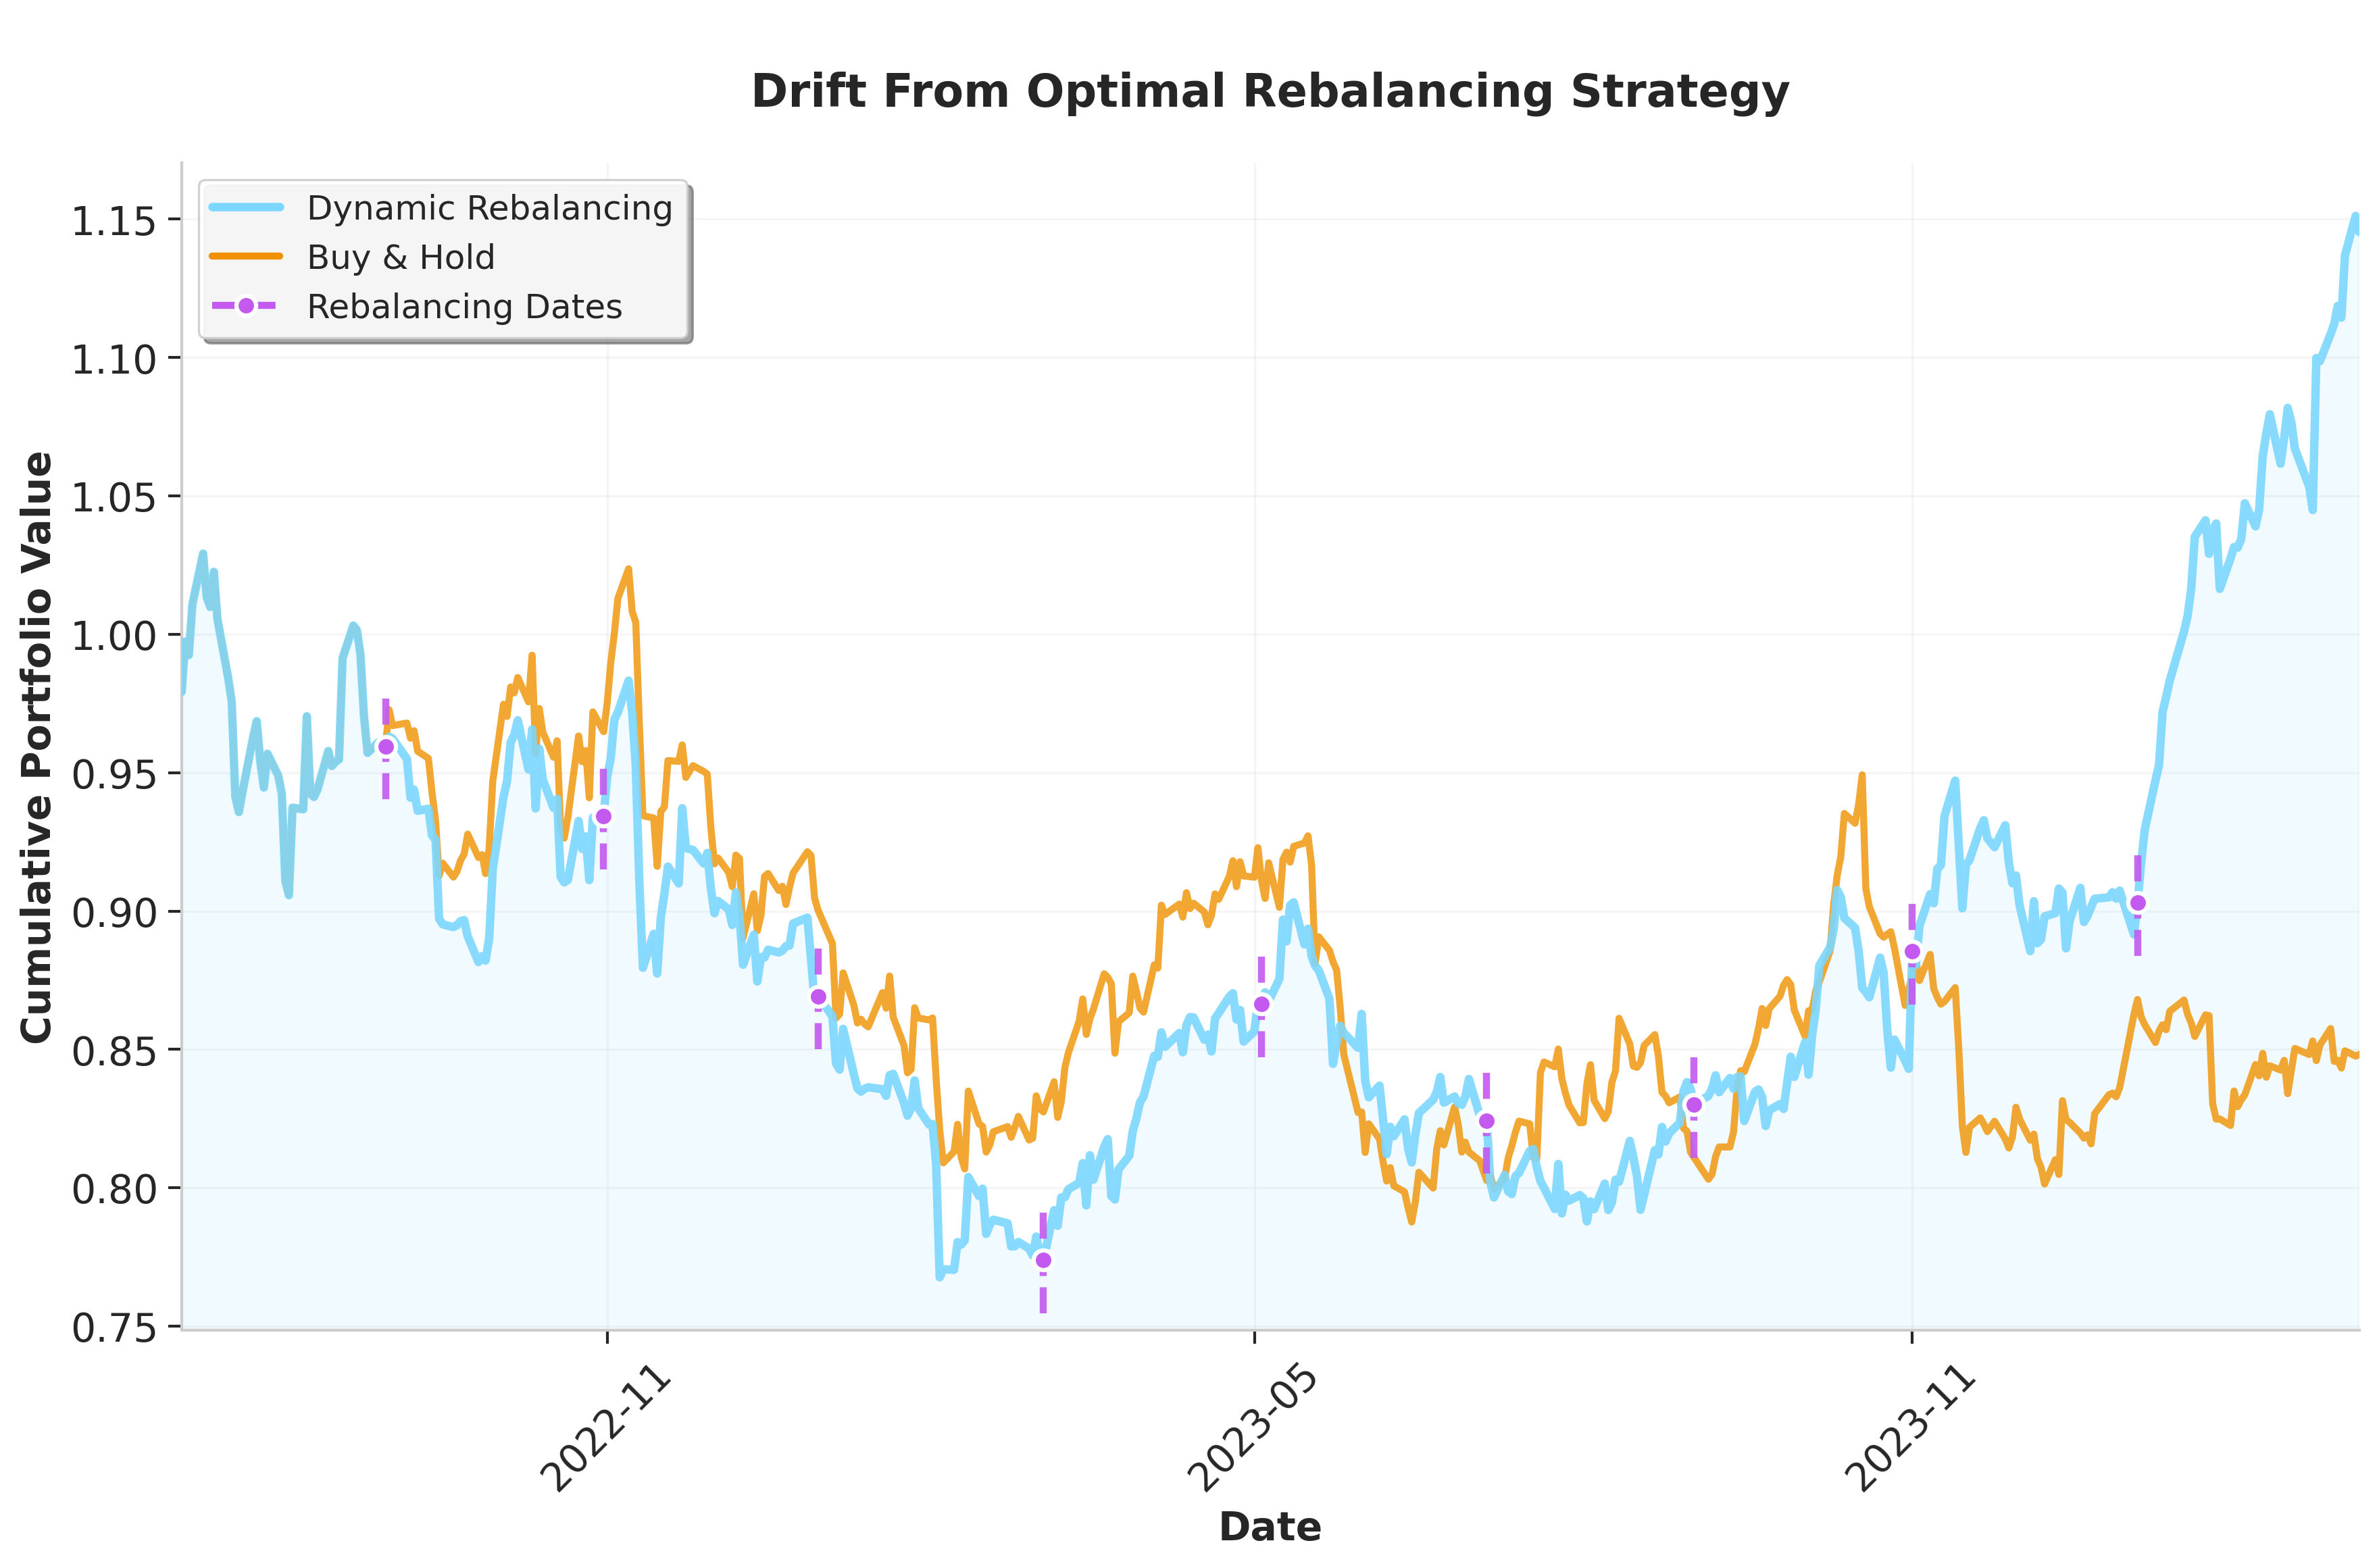

In [6]:
# --- Select Scenario for Rebalancing ---
selected_rebal_scenario_name = 'rebalancing_trading_period'
rebal_trading_start_date, rebal_trading_end_date = "2022-07-01", "2024-05-01"

# Look-back and look-forward windows for backtesting
rebal_look_back_window = 252       # Historical period used for optimization (trading days)
rebal_look_forward_window = 42     # Testing period (out-of-sample performance)

# Define drift tolerance threshold
drift_rebal_tolerance = 0.05        # Rebalance if weight deviation (L2 norm) exceeds tolerance

# Set re-optimization criteria for drift
drift_re_optimize_criteria = {
    "type": "drift_from_optimal",
    "threshold": drift_rebal_tolerance,
    "norm": 1,                # Using L2 norm
}

#GPU solver
solver_settings = {"solver": cp.CUOPT, "verbose": False, 'solver_method': 'PDLP'}

# Execute portfolio rebalancing
drift_rebalancing_obj = rebalance.rebalance_portfolio(
    dataset_directory=sp500_dataset_directory,
    returns_compute_settings = rebal_returns_compute_settings,
    scenario_generation_settings = rebal_scenario_generation_settings,
    trading_start=rebal_trading_start_date,
    trading_end=rebal_trading_end_date,
    look_forward_window=rebal_look_forward_window,
    look_back_window=rebal_look_back_window,
    cvar_params=rebal_tc_cvar_params,
    solver_settings = solver_settings,
    re_optimize_criteria=drift_re_optimize_criteria,
    print_opt_result=False
)

# Retrieve and plot results
drift_results_df, drift_re_optimize_dates, cumulative_portfolio_value_array = drift_rebalancing_obj.re_optimize(plot_results=True, save_plot = True, results_dir = "../results/rebalancing_strategies")

<a id="mean-variance"></a>
## 10. Mean-Variance Portfolio Optimization

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Optional Notebook</h4>
We also support solving <strong>Quadratic Programs (QP)</strong>, enabling standard <strong>Markowitz Mean-Variance</strong> portfolio optimization directly on the GPU.

This section shows how the same framework extends to QP problems with a quadratic objective using variance as the risk measure <code>w'Σw</code>.
</div>


In [2]:
import os

import numpy as np
import cvxpy as cp

from cufolio import mean_variance_optimizer, utils
from cufolio.mean_variance_parameters import MeanVarianceParameters
from cufolio.settings import ApiSettings, ReturnsComputeSettings

<a id='introduction'></a>
### Mathematical Formulation

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-Variance (Markowitz) Optimization</h4>
Mean-Variance optimization, introduced by Harry Markowitz in 1952, is the foundation of Modern Portfolio Theory. The objective trades off expected return against portfolio variance:

\begin{align*}
\text{maximize } \quad &\mu^\top w - \lambda_{\text{risk}} \cdot w^\top \Sigma w\\
\text{subject to} \quad 
& \sum_i w_i + c = 1 \quad \text{(self-financing)}\\
& w_i^{\text{min}} \leq w_i \leq w_i^{\text{max}}, \forall i \quad \text{(concentration)}\\
& c^{\text{min}} \leq c \leq c^{\text{max}} \quad \text{(cash)}\\
& L = \|w\|_1 \leq L^{\text{limit}} \quad \text{(leverage)}\\
& T = \|w - w_{\text{prev}}\|_1 \leq T^{\text{limit}} \quad \text{(turnover)}
\end{align*}

This is a **Quadratic Program (QP)** due to the $w^\top \Sigma w$ term. cuOpt 26.02 introduces QP support via a GPU-accelerated barrier solver.
</div>


<a id='solve'></a>
### Solve with cuOpt

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 End-to-End: Data → Parameters → GPU Solve</h4>
We load S&P 500 price data, compute log-returns, define portfolio constraints, and solve the QP on the GPU using cuOpt.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>


In [3]:
dataset_name = "sp500"
data_path = f"../data/stock_data/{dataset_name}.csv"

if not os.path.exists(data_path):
    utils.download_data(data_path)

returns_dict = utils.calculate_returns(
    data_path,
    {"name": "recent", "range": ("2022-01-01", "2024-01-01")},
    ReturnsComputeSettings(return_type="LOG", freq=1),
)

print(f"Assets: {len(returns_dict['tickers'])}  |  "
      f"Observations: {len(returns_dict['returns'])}  |  "
      f"Covariance: {returns_dict['covariance'].shape}")


Assets: 392  |  Observations: 500  |  Covariance: (392, 392)


In [4]:
mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},
    w_max={"NVDA": 0.6, "others": 0.4},
    c_min=0.0,
    c_max=0.2,
    L_tar=1.6,
    risk_aversion=1.0,
)


### Solve with CVXPY API

In [ ]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CUOPT, "time_limit": 60, "verbose": True}
)

(CVXPY) Apr 13 02:49:51 AM: Your problem has 393 variables, 2 constraints, and 2 parameters.
(CVXPY) Apr 13 02:49:51 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 13 02:49:51 AM: DCP verification time: 0.0001 seconds.
(CVXPY) Apr 13 02:49:51 AM: Expression tree has 8 nodes.
(CVXPY) Apr 13 02:49:51 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 13 02:49:51 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 13 02:49:51 AM: Compiling problem (target solver=CUOPT).
(CVXPY) Apr 13 02:49:51 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> CUOPT
(CVXPY) Apr 13 02:49:51 AM: Applying reduction Dcp2Cone
(CVXPY) Apr 13 02:49:51 AM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 13 02:49:51 AM: Applying reduction EliminateZeroSized
(CVXPY) Apr 13 02:49:51 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 13 02:49:51 AM: Applyin

                                     CVXPY                                     
                             v1.9.0.dev0+0.f006ffa                             
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Apr 13 02:49:51 AM: Problem status: optimal
(CVXPY) Apr 13 02:49:51 AM: Optimal value: -2.890e-03
(CVXPY) Apr 13 02:49:51 AM: Compilation took 2.819e-02 seconds
(CVXPY) Apr 13 02:49:51 AM: Solver (including time spent in interface) took 2.591e-01 seconds


Setting parameter log_to_console to true
Setting parameter time_limit to 6.000000e+01
cuOpt version: 26.2.0, git hash: f73da24d, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480C, threads (physical/logical): 112/224, RAM: 1965.85 GiB
CUDA 13.1, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: ffffffdbfffffffb4372-ffffffce15-ffff

Problem has a quadratic objective. Using Barrier.
Solving a problem with 786 constraints, 785 variables (0 integers), and 2353 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party presolve is disabled, skipping
Objective offset 0.000000 scaling_factor 1.000000
Transforming 392 nonzero lower bound
Presolved problem: 786 constraints 1962 variables 641245304 nonzeros
Skipping col

### Solve using cuOpt Python API

In [ ]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cuopt_python"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"time_limit": 60, "log_to_console": True}
)

cuOpt MEAN-VARIANCE (QP) PROBLEM SETUP COMPLETED
Variables: 392 weights + 1 cash + 784 leverage aux
Covariance matrix: 392x392
Linear terms: 392
Problem Type: QP (Quadratic Programming)
Setting parameter time_limit to 6.000000e+01
Setting parameter log_to_console to true
cuOpt version: 26.2.0, git hash: f73da24d, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480C, threads (physical/logical): 112/224, RAM: 1965.74 GiB
CUDA 13.1, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: ffffffdbfffffffb4372-ffffffce15-ffff

Problem has a quadratic objective. Using Barrier.
Solving a problem with 394 constraints, 1177 variables (0 integers), and 2353 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party presolve is 

regime          recent
solver           cuOpt
solve time    0.158607
return        0.002914
variance      0.000235
obj          -0.002892
dtype: object

<a id='analyze'></a>
### Results


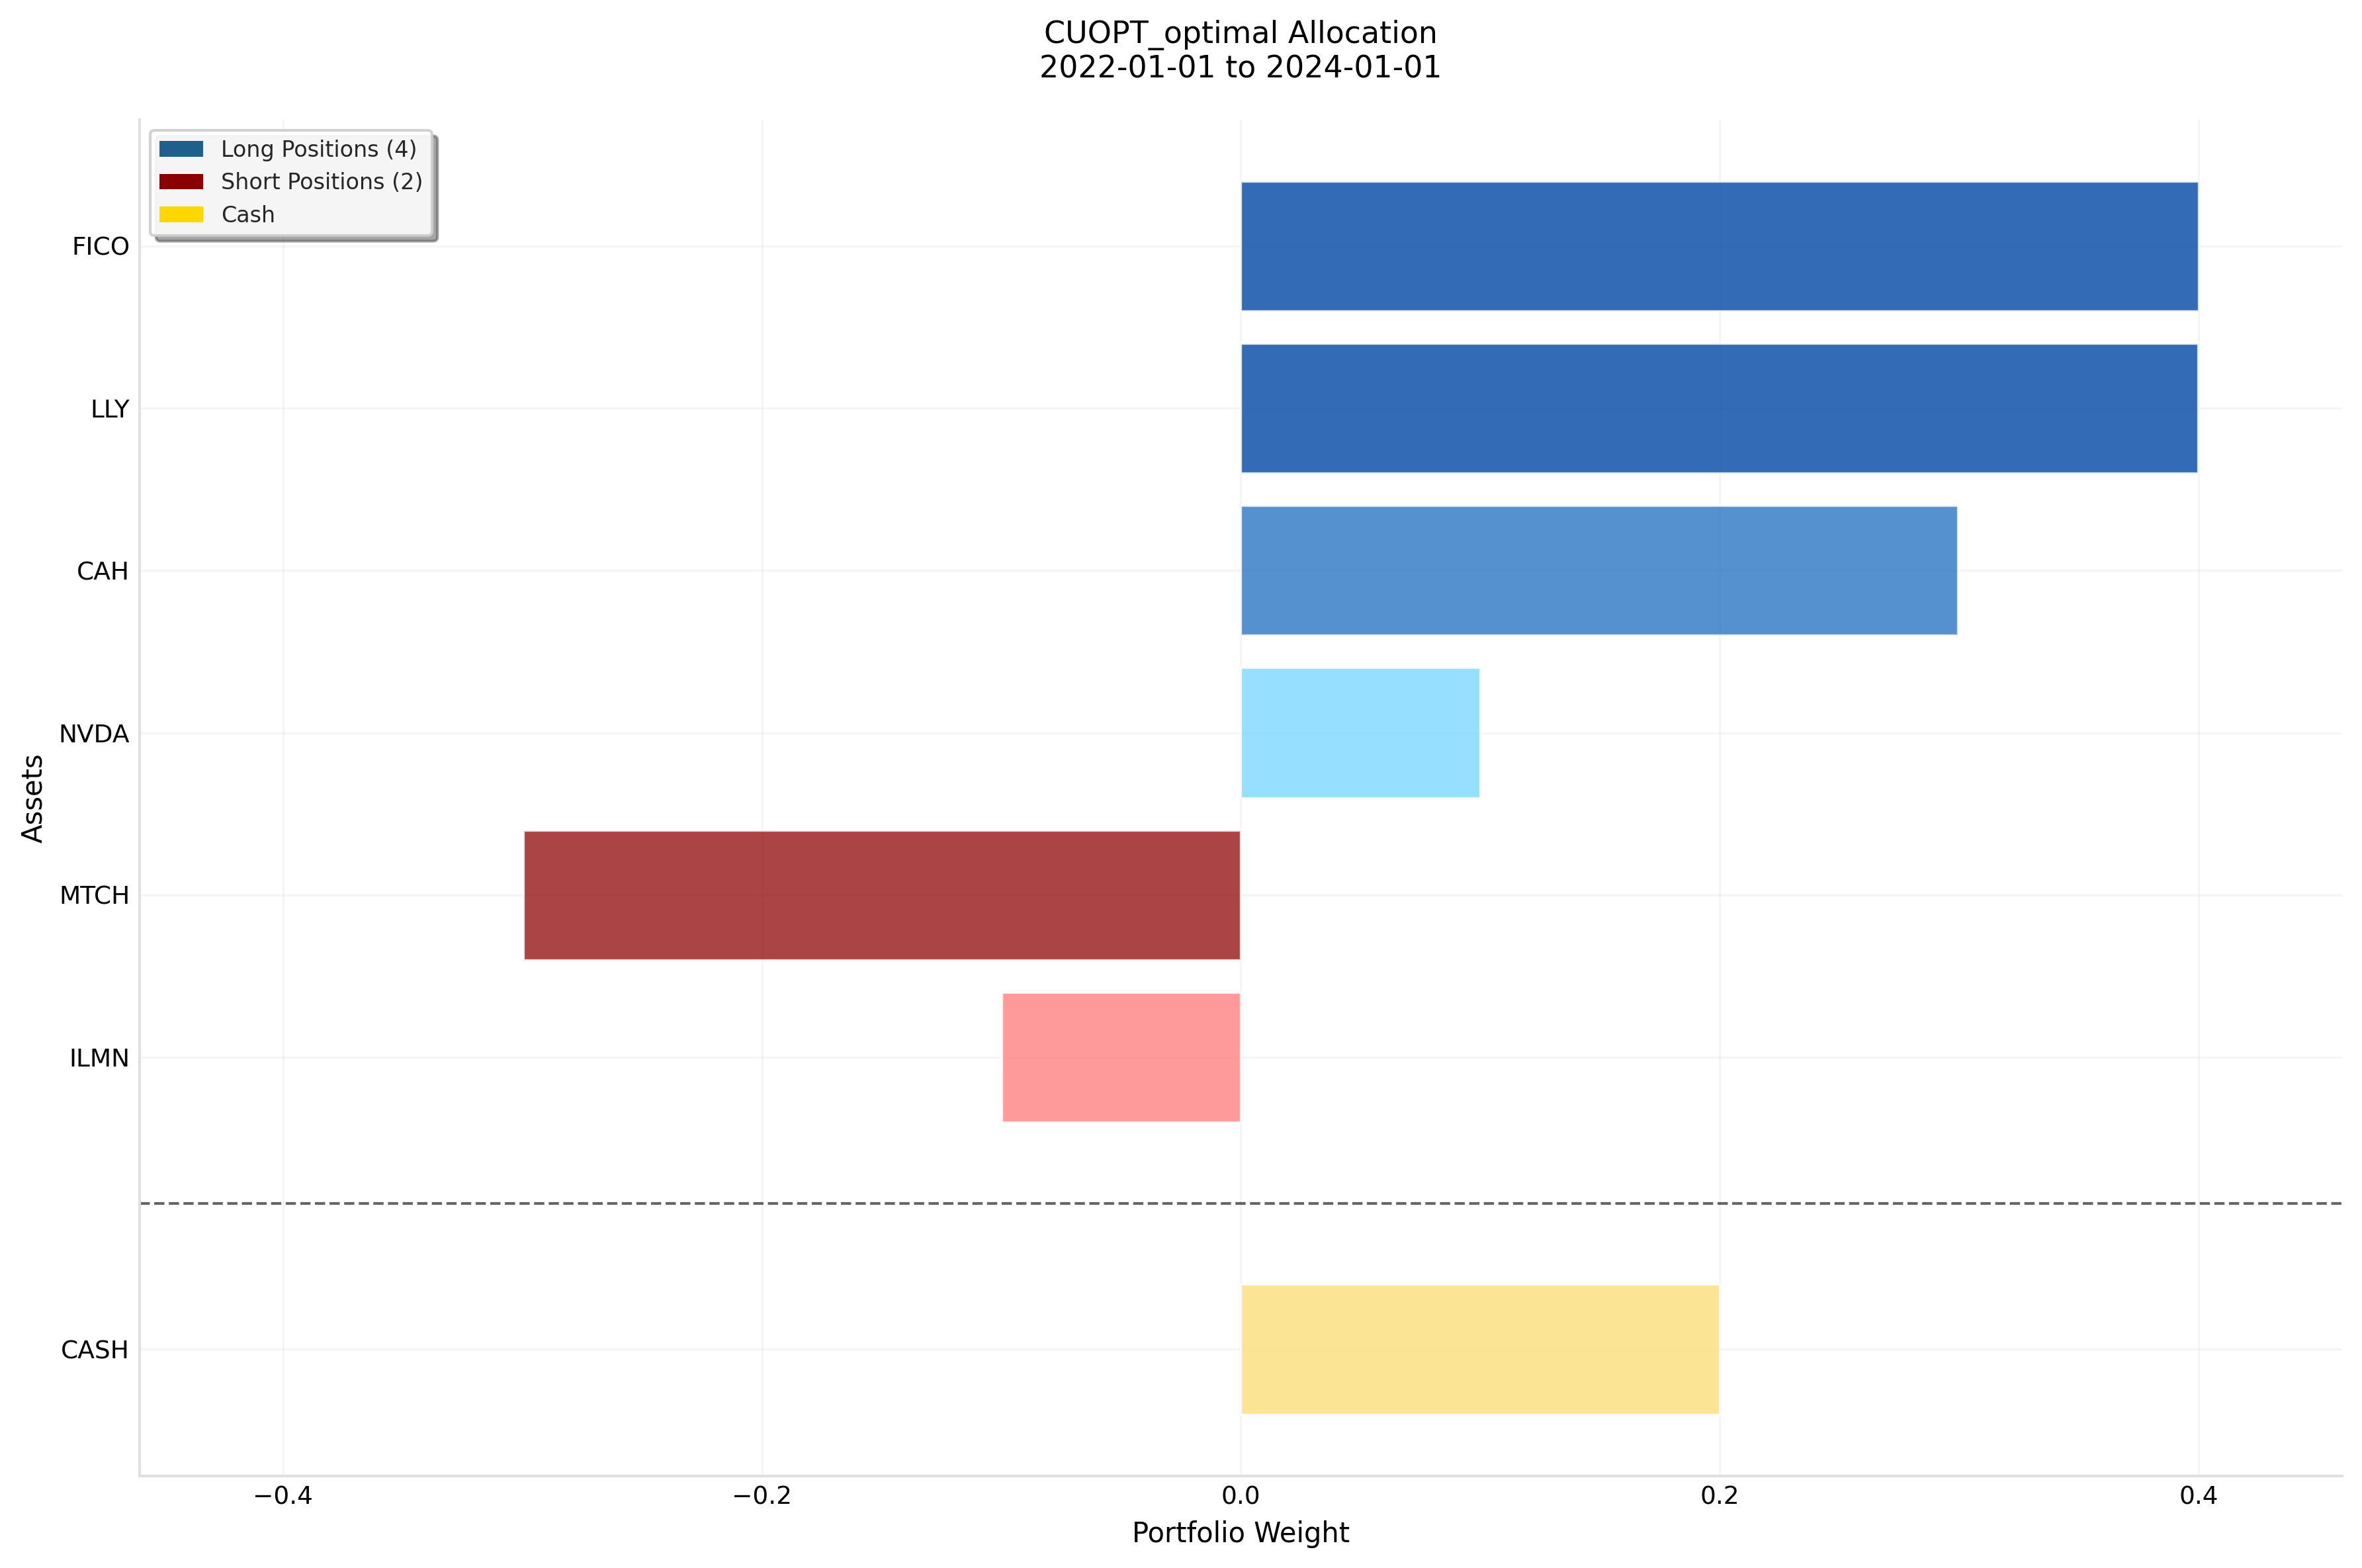

In [10]:
ax = gpu_portfolio.plot_portfolio(show_plot=True, min_percentage=1)


In [8]:
weights = gpu_portfolio.weights

expected_return = np.dot(returns_dict["mean"], weights)
portfolio_variance = weights @ returns_dict["covariance"] @ weights
portfolio_std = np.sqrt(portfolio_variance)
sharpe_ratio = expected_return / portfolio_std if portfolio_std > 0 else 0

print("Portfolio Statistics:")
print(f"  Expected Return: {expected_return:.4%}")
print(f"  Volatility (Std): {portfolio_std:.4%}")
print(f"  Variance: {portfolio_variance:.6f}")
print(f"  Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"  Cash Allocation: {gpu_portfolio.cash:.2%}")
print(f"  Leverage: {np.sum(np.abs(weights)):.4f}")
print(f"  Number of positions: {np.sum(np.abs(weights) > 0.001)}")


Portfolio Statistics:
  Expected Return: 0.2912%
  Volatility (Std): 1.5320%
  Variance: 0.000235
  Sharpe Ratio: 0.1901
  Cash Allocation: 20.00%
  Leverage: 1.5994
  Number of positions: 6


<a id='cpu-comparison'></a>
### CPU Solver Comparison

<div style="background-color: #fff3e0; border-left: 6px solid #f57c00; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🔄 GPU vs CPU</h4>
Solve the same Mean-Variance problem using <strong>Clarabel</strong> (a CPU-based interior-point solver) and compare the results against the GPU solution above. For small portfolios the GPU advantage in solve time alone may be modest, but running the entire pipeline on GPU — data preprocessing, returns forecasting, scenario generation, and optimization — eliminates costly CPU↔GPU data transfers and delivers end-to-end speedups that grow with problem size.
</div>

In [16]:
cpu_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

cpu_results, cpu_portfolio = cpu_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CLARABEL}
)


MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2022-01-01 to 2024-01-01
Assets:              392

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002914 (0.2914%)
Variance:            0.000235
Std Deviation:       0.015327
Objective Value:     -0.002892

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.0006 seconds
CVXPY API Overhead:  0.0071 seconds
Solve Time:          0.0974 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2022-01-01 to 2024-01-01

LONG POSITIONS (4 assets)
-------------------------
FICO        0.400 ( 40.00%)
LLY         0.400 ( 40.00%)
CAH         0.300 ( 30.00%)
NVDA        0.100 ( 10.00%)
Total Long    1.200 (120.00%)

SHORT POSITIONS (2 assets)
--------------------------
MTCH       -0.300 (-30.00

In [15]:
utils.compare_results(gpu_results.to_dict(), cpu_results.to_dict())


SOLVER COMPARISON
Solver          solve time   obj          return       variance    
----------------------------------------------------------------------
cuOpt           0.158607     -0.002892    0.002914     0.000235    
CLARABEL        0.097250     -0.002892    0.002914     0.000235    

Objective Differences:
  cuOpt vs CLARABEL: 0.00000010



### Summary

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">✅ Key Takeaway</h4>
<strong>cuOpt >= 26.02</strong> adds QP support, enabling GPU-accelerated Markowitz Mean-Variance optimization alongside the existing LP-based CVaR solver. The same cuFOLIO framework handles both problem types — simply choose the appropriate optimizer class.

#### Mean-Variance vs CVaR

| Aspect | Mean-Variance | CVaR |
|--------|---------------|------|
| Risk Measure | Variance (symmetric) | Tail risk (asymmetric) |
| Problem Type | QP (Quadratic) | LP (Linear) |
| Data Needed | Mean + Covariance | Scenarios |
| Distribution | Assumes normal | Distribution-free |

</div>


SPDX-FileCopyrightText: Copyright (c) 2023-2025 NVIDIA CORPORATION & AFFILIATES. All rights reserved. 

SPDX-License-Identifier: Apache-2.0

Licensed under the Apache License, Version 2.0 (the "License");you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.